# Mini Project 2 - Fundamentals of Intelligent Systems

**Name:** Niki Mahdian  
**Student ID:** 401231053

---

# Question 6: RBF Neural Network Implementation


In [174]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, mean_absolute_error
import os
import warnings
warnings.filterwarnings('ignore')

# Create plots directory if it doesn't exist
os.makedirs('plots', exist_ok=True)

# Set plot style for better visualization
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True

print("✓ Setup complete! All plots will be saved to 'plots/' folder.")


✓ Setup complete! All plots will be saved to 'plots/' folder.


## Part 1


In [175]:
# =====================================================
# 1.1.1 - Generate Ball and Beam Dataset
# =====================================================

def generate_ball_beam_data(n_samples=1000):
    """
    Generate Ball and Beam system data.
    System dynamics: y(t) = y(t-1)/(1 + y(t-2)) + u(t-1)^3
    Input signal: u(t) = sin(2*pi*t/250)
    """
    # Time array
    t = np.arange(n_samples)
    
    # Input signal: sinusoidal
    u = np.sin(2 * np.pi * t / 250)
    
    # Initialize output array
    y = np.zeros(n_samples)
    
    # Initial conditions: y(0) = y(1) = 0
    y[0] = 0
    y[1] = 0
    
    # Generate system output using difference equation
    for i in range(2, n_samples):
        y[i] = y[i-1] / (1 + y[i-2]) + u[i-1]**3
    
    return t, u, y

# Generate data
t, u, y = generate_ball_beam_data(1000)

# Create input-output pairs for RBFNN
# Input: x(t) = [y(t-1), y(t-2), u(t-1)]
# Output: y(t)
X = np.column_stack([y[1:-1], y[0:-2], u[1:-1]])  # From t=2 to t=999
Y = y[2:]  # y(t) from t=2 to t=999

print(f"Dataset generated successfully!")
print(f"Total samples: {len(Y)}")
print(f"Input shape X: {X.shape} (features: y(t-1), y(t-2), u(t-1))")
print(f"Output shape Y: {Y.shape}")


Dataset generated successfully!
Total samples: 998
Input shape X: (998, 3) (features: y(t-1), y(t-2), u(t-1))
Output shape Y: (998,)


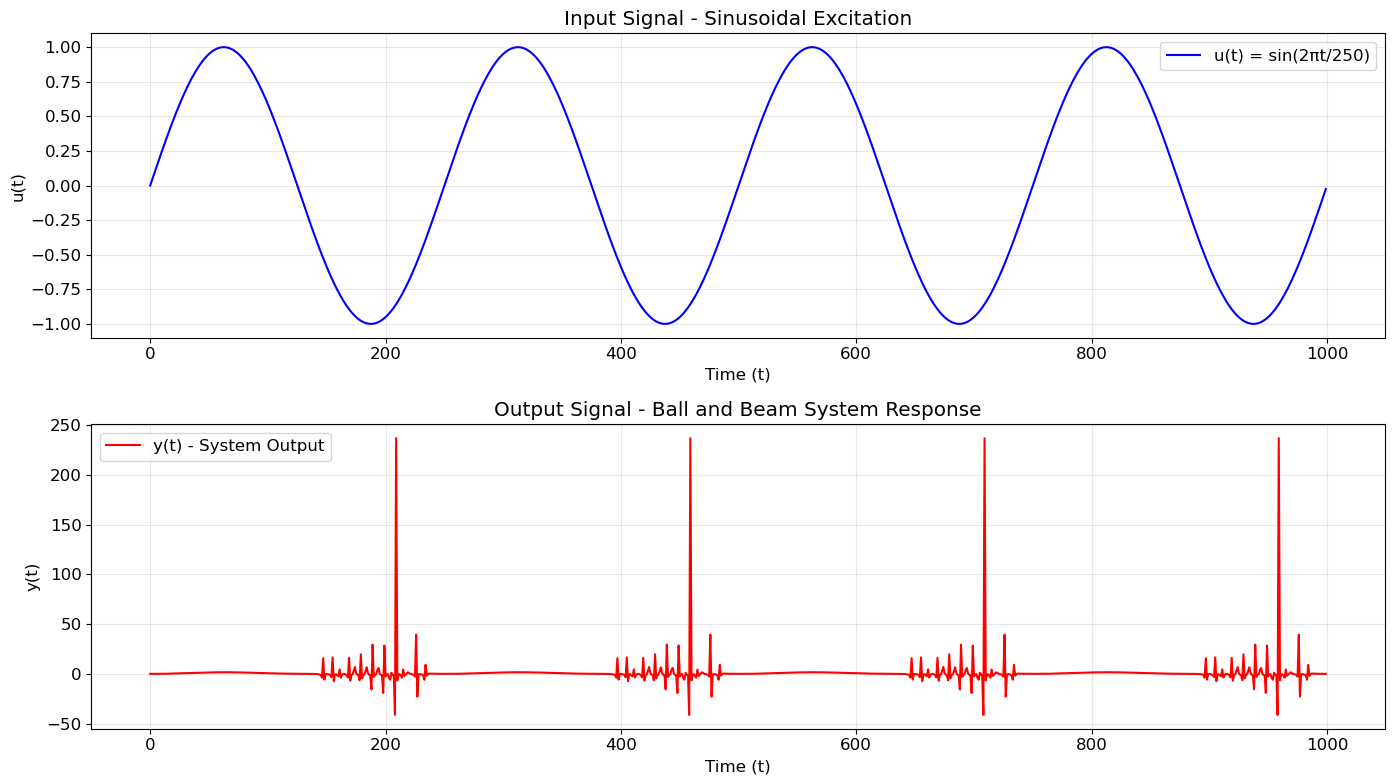

✓ Plot saved: plots/Q6_1_ball_beam_data.png


In [176]:
# Visualize the Ball and Beam system data
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot input signal u(t)
axes[0].plot(t, u, 'b-', linewidth=1.5, label='u(t) = sin(2πt/250)')
axes[0].set_xlabel('Time (t)')
axes[0].set_ylabel('u(t)')
axes[0].set_title('Input Signal - Sinusoidal Excitation')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot output signal y(t)
axes[1].plot(t, y, 'r-', linewidth=1.5, label='y(t) - System Output')
axes[1].set_xlabel('Time (t)')
axes[1].set_ylabel('y(t)')
axes[1].set_title('Output Signal - Ball and Beam System Response')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/Q6_1_ball_beam_data.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved: plots/Q6_1_ball_beam_data.png")


In [177]:
# =====================================================
# 2.1.1 - Train/Test Split
# =====================================================

# Split data: 700 for training, 300 for testing
train_size = 700

X_train = X[:train_size]
Y_train = Y[:train_size]
X_test = X[train_size:]
Y_test = Y[train_size:]

print("Data split completed!")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining input shape: {X_train.shape}")
print(f"Training output shape: {Y_train.shape}")
print(f"Test input shape: {X_test.shape}")
print(f"Test output shape: {Y_test.shape}")


Data split completed!
Training set: 700 samples
Test set: 298 samples

Training input shape: (700, 3)
Training output shape: (700,)
Test input shape: (298, 3)
Test output shape: (298,)


## Part 2


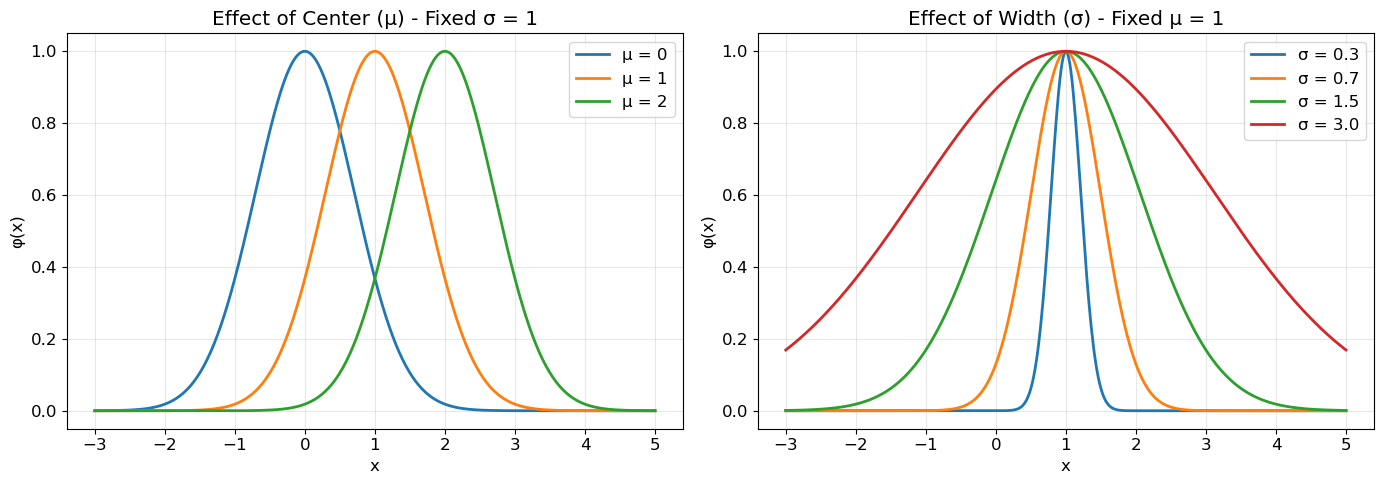

✓ Plot saved: plots/Q6_2_rbf_center_width_effect.png


In [178]:
# =====================================================
# Visualize the effect of center (μ) and width (σ)
# =====================================================

# Create 1D example to show the effect of μ and σ
x_range = np.linspace(-3, 5, 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Effect of different centers
centers = [0, 1, 2]
sigma = 1
for mu in centers:
    phi = np.exp(-((x_range - mu)**2) / (sigma**2))
    axes[0].plot(x_range, phi, linewidth=2, label=f'μ = {mu}')
axes[0].set_xlabel('x')
axes[0].set_ylabel('φ(x)')
axes[0].set_title('Effect of Center (μ) - Fixed σ = 1')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Effect of different widths
mu = 1
sigmas = [0.3, 0.7, 1.5, 3.0]
for sigma in sigmas:
    phi = np.exp(-((x_range - mu)**2) / (sigma**2))
    axes[1].plot(x_range, phi, linewidth=2, label=f'σ = {sigma}')
axes[1].set_xlabel('x')
axes[1].set_ylabel('φ(x)')
axes[1].set_title('Effect of Width (σ) - Fixed μ = 1')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/Q6_2_rbf_center_width_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved: plots/Q6_2_rbf_center_width_effect.png")


In [179]:
# =====================================================
# 2.2.1 - Define RBF Gaussian Activation Function
# =====================================================

def rbf_gaussian(x, mu, sigma):
    """
    Compute Gaussian RBF activation.
    
    Parameters:
    -----------
    x : array-like
        Input vector
    mu : array-like
        Center of the RBF neuron
    sigma : float
        Width of the RBF neuron
        
    Returns:
    --------
    phi : float
        RBF activation value
    """
    x = np.array(x)
    mu = np.array(mu)
    
    # Euclidean distance squared
    dist_squared = np.sum((x - mu)**2)
    
    # Gaussian RBF
    phi = np.exp(-dist_squared / (sigma**2))
    
    return phi

# Test the RBF function with μ = [1, 1] and σ = 1
mu_test = np.array([1, 1])
sigma_test = 1

# Test with different input vectors
test_inputs = [
    [1, 1],      # Exactly at center
    [0, 0],      # Origin
    [1, 0],      # Partially at center
    [2, 2],      # Away from center
    [0.5, 0.5],  # Halfway to center
]

print("Testing RBF function with μ = [1, 1] and σ = 1")
print("=" * 50)
for x in test_inputs:
    phi = rbf_gaussian(x, mu_test, sigma_test)
    dist = np.sqrt(np.sum((np.array(x) - mu_test)**2))
    print(f"x = {str(x):15s} | distance = {dist:.4f} | φ(x) = {phi:.6f}")


Testing RBF function with μ = [1, 1] and σ = 1
x = [1, 1]          | distance = 0.0000 | φ(x) = 1.000000
x = [0, 0]          | distance = 1.4142 | φ(x) = 0.135335
x = [1, 0]          | distance = 1.0000 | φ(x) = 0.367879
x = [2, 2]          | distance = 1.4142 | φ(x) = 0.135335
x = [0.5, 0.5]      | distance = 0.7071 | φ(x) = 0.606531


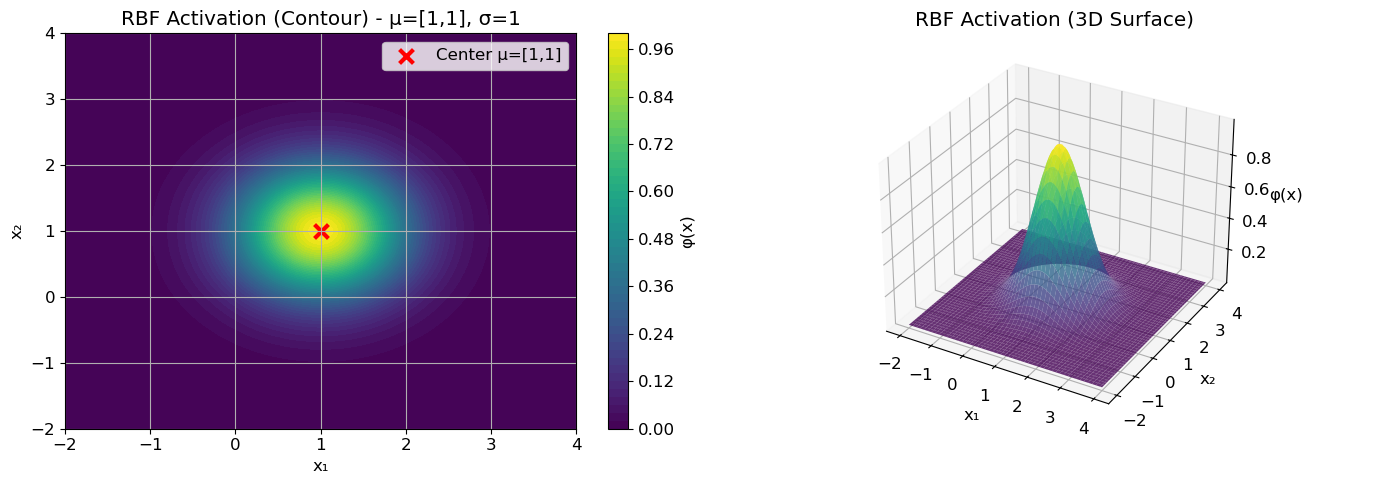

✓ Plot saved: plots/Q6_3_rbf_2d_visualization.png


In [180]:
# Visualize RBF activation in 2D space with μ = [1, 1] and σ = 1
x1_range = np.linspace(-2, 4, 100)
x2_range = np.linspace(-2, 4, 100)
X1, X2 = np.meshgrid(x1_range, x2_range)

# Calculate RBF activation for each point
Z = np.zeros_like(X1)
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        Z[i, j] = rbf_gaussian([X1[i, j], X2[i, j]], mu_test, sigma_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contour plot
contour = axes[0].contourf(X1, X2, Z, levels=50, cmap='viridis')
axes[0].scatter(mu_test[0], mu_test[1], c='red', s=100, marker='x', linewidths=3, label='Center μ=[1,1]')
axes[0].set_xlabel('x₁')
axes[0].set_ylabel('x₂')
axes[0].set_title('RBF Activation (Contour) - μ=[1,1], σ=1')
axes[0].legend()
plt.colorbar(contour, ax=axes[0], label='φ(x)')

# 3D surface plot
from mpl_toolkits.mplot3d import Axes3D
ax3d = fig.add_subplot(1, 2, 2, projection='3d')
ax3d.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.8)
ax3d.set_xlabel('x₁')
ax3d.set_ylabel('x₂')
ax3d.set_zlabel('φ(x)')
ax3d.set_title('RBF Activation (3D Surface)')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('plots/Q6_3_rbf_2d_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved: plots/Q6_3_rbf_2d_visualization.png")


In [181]:
# =====================================================
# Complete Static RBFNN Implementation
# =====================================================

class StaticRBFNN:
    """
    Static Radial Basis Function Neural Network.
    
    Architecture:
    - Input layer: receives input vector x
    - Hidden layer: K RBF neurons with Gaussian activation
    - Output layer: linear combination of hidden outputs
    
    Training:
    - Centers (μ): determined using K-Means clustering
    - Widths (σ): calculated based on distances between centers
    - Output weights (α): trained using Least Squares
    """
    
    def __init__(self, n_hidden=20, sigma_scale=1.0):
        """
        Initialize RBFNN.
        
        Parameters:
        -----------
        n_hidden : int
            Number of hidden RBF neurons (K)
        sigma_scale : float
            Scaling factor for widths
        """
        self.n_hidden = n_hidden
        self.sigma_scale = sigma_scale
        self.centers = None      # μ_k
        self.sigmas = None       # σ_k
        self.weights = None      # α_k
        
    def _compute_rbf(self, X, center, sigma):
        """Compute Gaussian RBF activation for all samples."""
        # ||x - μ||²
        dist_squared = np.sum((X - center)**2, axis=1)
        return np.exp(-dist_squared / (sigma**2))
    
    def _compute_hidden_output(self, X):
        """Compute output of all hidden neurons for all samples."""
        n_samples = X.shape[0]
        Phi = np.zeros((n_samples, self.n_hidden))
        
        for k in range(self.n_hidden):
            Phi[:, k] = self._compute_rbf(X, self.centers[k], self.sigmas[k])
            
        return Phi
    
    def fit(self, X, y):
        """
        Train the RBFNN using Least Squares.
        
        Parameters:
        -----------
        X : array of shape (n_samples, n_features)
            Training input data
        y : array of shape (n_samples,)
            Training target values
        """
        n_samples, n_features = X.shape
        
        # Step 1: Determine centers using K-Means clustering
        print(f"Step 1: Finding {self.n_hidden} centers using K-Means...")
        kmeans = KMeans(n_clusters=self.n_hidden, random_state=42, n_init=10)
        kmeans.fit(X)
        self.centers = kmeans.cluster_centers_
        
        # Step 2: Calculate widths (σ) based on distances between centers
        print("Step 2: Calculating widths (σ)...")
        # Use average distance to nearest centers
        self.sigmas = np.zeros(self.n_hidden)
        for k in range(self.n_hidden):
            # Distance to all other centers
            distances = np.sqrt(np.sum((self.centers - self.centers[k])**2, axis=1))
            distances = distances[distances > 0]  # Exclude self
            # σ = average distance to nearest neighbors * scale
            self.sigmas[k] = np.mean(np.sort(distances)[:3]) * self.sigma_scale
        
        # Ensure minimum sigma value
        self.sigmas = np.maximum(self.sigmas, 0.1)
        
        # Step 3: Compute hidden layer output matrix Φ
        print("Step 3: Computing hidden layer output matrix...")
        Phi = self._compute_hidden_output(X)
        
        # Step 4: Solve for weights using Least Squares: Φ * α = y
        # α = (Φᵀ Φ)⁻¹ Φᵀ y (pseudo-inverse)
        print("Step 4: Training output weights using Least Squares...")
        self.weights = np.linalg.lstsq(Phi, y, rcond=None)[0]
        
        print("Training complete!")
        return self
    
    def predict(self, X):
        """
        Predict output for input samples.
        
        Parameters:
        -----------
        X : array of shape (n_samples, n_features)
            Input data
            
        Returns:
        --------
        y_pred : array of shape (n_samples,)
            Predicted output
        """
        Phi = self._compute_hidden_output(X)
        return Phi @ self.weights
    
    def score(self, X, y):
        """Calculate R² score."""
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        return 1 - (ss_res / ss_tot)

print("✓ StaticRBFNN class defined successfully!")


✓ StaticRBFNN class defined successfully!


In [182]:
# =====================================================
# Train and Evaluate RBFNN
# =====================================================

# Create and train the RBFNN
n_neurons = 25  # Number of hidden neurons
rbfnn = StaticRBFNN(n_hidden=n_neurons, sigma_scale=1.0)

print("="*60)
print(f"Training Static RBFNN with {n_neurons} hidden neurons")
print("="*60)
rbfnn.fit(X_train, Y_train)

# Make predictions
Y_train_pred = rbfnn.predict(X_train)
Y_test_pred = rbfnn.predict(X_test)

# Calculate metrics
train_mse = mean_squared_error(Y_train, Y_train_pred)
test_mse = mean_squared_error(Y_test, Y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
train_mae = mean_absolute_error(Y_train, Y_train_pred)
test_mae = mean_absolute_error(Y_test, Y_test_pred)
train_r2 = rbfnn.score(X_train, Y_train)
test_r2 = rbfnn.score(X_test, Y_test)

print("\n" + "="*60)
print("Performance Metrics")
print("="*60)
print(f"{'Metric':<15} {'Training':>15} {'Test':>15}")
print("-"*45)
print(f"{'MSE':<15} {train_mse:>15.6f} {test_mse:>15.6f}")
print(f"{'RMSE':<15} {train_rmse:>15.6f} {test_rmse:>15.6f}")
print(f"{'MAE':<15} {train_mae:>15.6f} {test_mae:>15.6f}")
print(f"{'R² Score':<15} {train_r2:>15.6f} {test_r2:>15.6f}")


Training Static RBFNN with 25 hidden neurons
Step 1: Finding 25 centers using K-Means...
Step 2: Calculating widths (σ)...
Step 3: Computing hidden layer output matrix...
Step 4: Training output weights using Least Squares...
Training complete!

Performance Metrics
Metric                 Training            Test
---------------------------------------------
MSE                   14.085656       24.442803
RMSE                   3.753086        4.943966
MAE                    1.423511        1.831230
R² Score               0.924916        0.940917


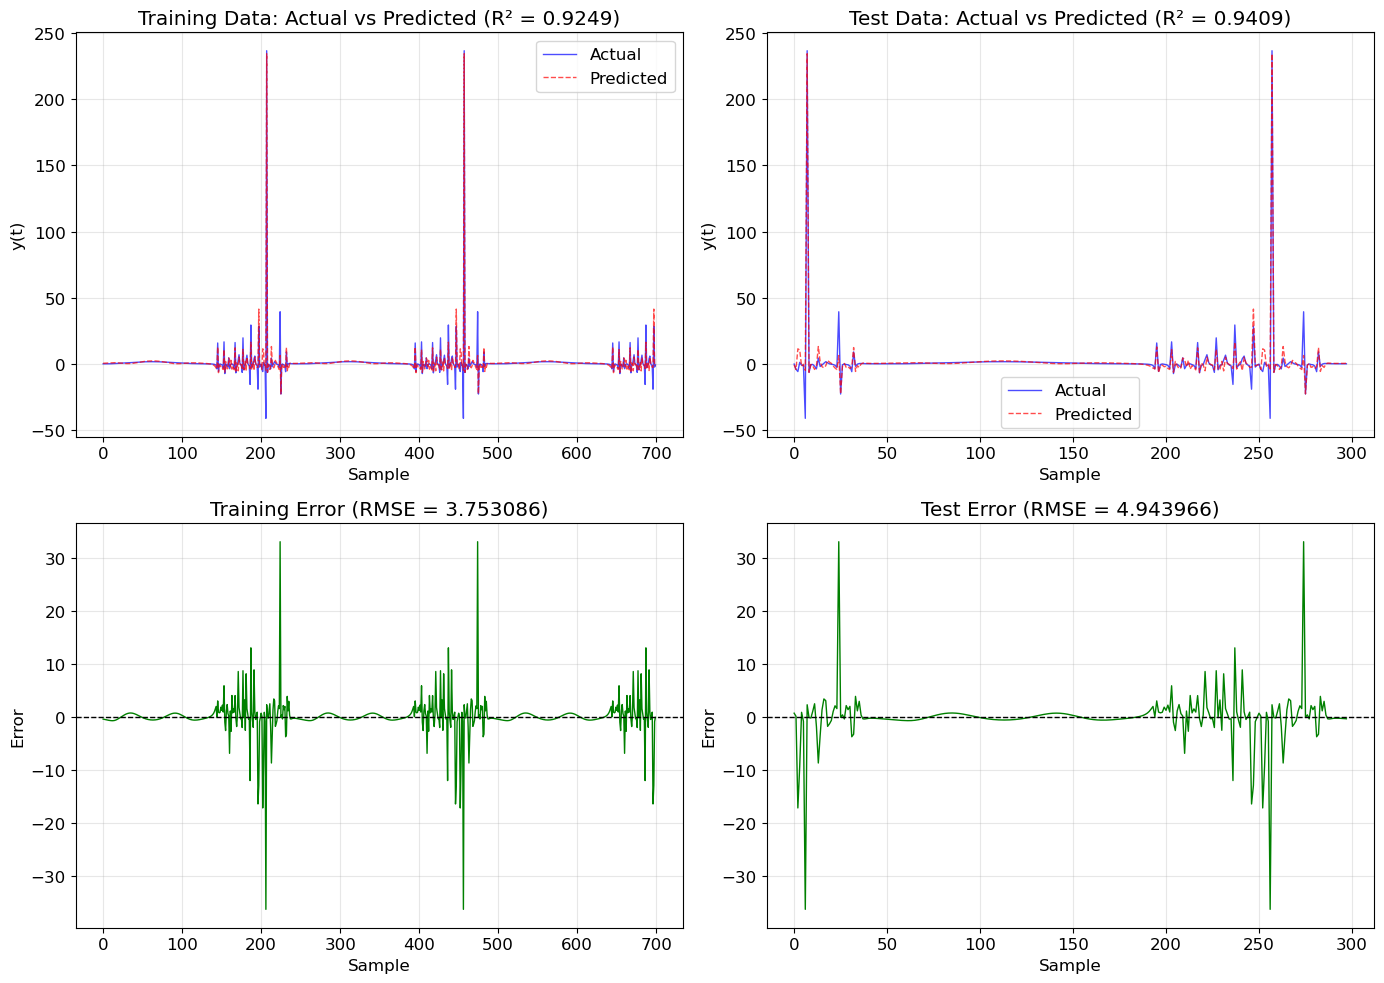

✓ Plot saved: plots/Q6_4_rbfnn_results.png


In [183]:
# =====================================================
# Visualize Training Results
# =====================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Training data: Actual vs Predicted
axes[0, 0].plot(Y_train, 'b-', linewidth=1, alpha=0.7, label='Actual')
axes[0, 0].plot(Y_train_pred, 'r--', linewidth=1, alpha=0.7, label='Predicted')
axes[0, 0].set_xlabel('Sample')
axes[0, 0].set_ylabel('y(t)')
axes[0, 0].set_title(f'Training Data: Actual vs Predicted (R² = {train_r2:.4f})')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Test data: Actual vs Predicted
axes[0, 1].plot(Y_test, 'b-', linewidth=1, alpha=0.7, label='Actual')
axes[0, 1].plot(Y_test_pred, 'r--', linewidth=1, alpha=0.7, label='Predicted')
axes[0, 1].set_xlabel('Sample')
axes[0, 1].set_ylabel('y(t)')
axes[0, 1].set_title(f'Test Data: Actual vs Predicted (R² = {test_r2:.4f})')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Training error
train_error = Y_train - Y_train_pred
axes[1, 0].plot(train_error, 'g-', linewidth=1)
axes[1, 0].axhline(y=0, color='k', linestyle='--', linewidth=1)
axes[1, 0].set_xlabel('Sample')
axes[1, 0].set_ylabel('Error')
axes[1, 0].set_title(f'Training Error (RMSE = {train_rmse:.6f})')
axes[1, 0].grid(True, alpha=0.3)

# Test error
test_error = Y_test - Y_test_pred
axes[1, 1].plot(test_error, 'g-', linewidth=1)
axes[1, 1].axhline(y=0, color='k', linestyle='--', linewidth=1)
axes[1, 1].set_xlabel('Sample')
axes[1, 1].set_ylabel('Error')
axes[1, 1].set_title(f'Test Error (RMSE = {test_rmse:.6f})')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/Q6_4_rbfnn_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved: plots/Q6_4_rbfnn_results.png")


Analyzing effect of number of hidden neurons...
Step 1: Finding 5 centers using K-Means...
Step 2: Calculating widths (σ)...
Step 3: Computing hidden layer output matrix...
Step 4: Training output weights using Least Squares...
Training complete!
K =   5: Train R² = 0.2118, Test R² = 0.2510
Step 1: Finding 10 centers using K-Means...
Step 2: Calculating widths (σ)...
Step 3: Computing hidden layer output matrix...
Step 4: Training output weights using Least Squares...
Training complete!
K =  10: Train R² = 0.8648, Test R² = 0.9039
Step 1: Finding 15 centers using K-Means...
Step 2: Calculating widths (σ)...
Step 3: Computing hidden layer output matrix...
Step 4: Training output weights using Least Squares...
Training complete!
K =  15: Train R² = 0.8953, Test R² = 0.9255
Step 1: Finding 20 centers using K-Means...
Step 2: Calculating widths (σ)...
Step 3: Computing hidden layer output matrix...
Step 4: Training output weights using Least Squares...
Training complete!
K =  20: Train R² 

Step 2: Calculating widths (σ)...
Step 3: Computing hidden layer output matrix...
Step 4: Training output weights using Least Squares...
Training complete!
K =  40: Train R² = 0.9517, Test R² = 0.9610
Step 1: Finding 50 centers using K-Means...
Step 2: Calculating widths (σ)...
Step 3: Computing hidden layer output matrix...
Step 4: Training output weights using Least Squares...
Training complete!
K =  50: Train R² = 0.9645, Test R² = 0.9714


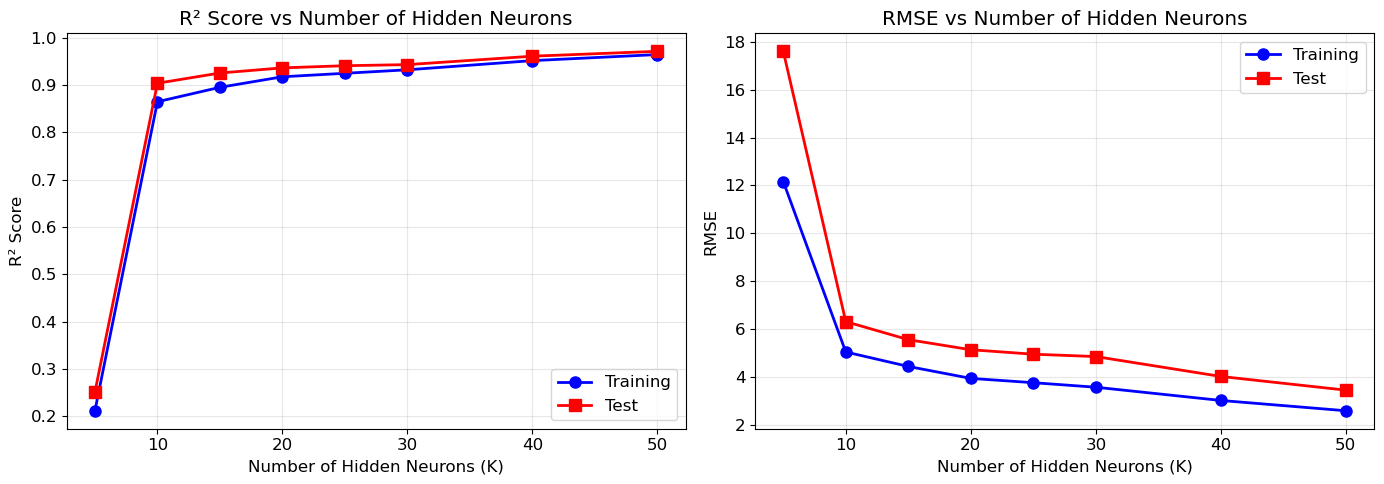


✓ Plot saved: plots/Q6_5_neurons_analysis.png


In [184]:
# =====================================================
# Effect of Number of Hidden Neurons
# =====================================================

neuron_counts = [5, 10, 15, 20, 25, 30, 40, 50]
train_r2_scores = []
test_r2_scores = []
train_rmse_scores = []
test_rmse_scores = []

print("Analyzing effect of number of hidden neurons...")
print("="*60)

for n in neuron_counts:
    model = StaticRBFNN(n_hidden=n, sigma_scale=1.0)
    model.fit(X_train, Y_train)
    
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_r2_scores.append(model.score(X_train, Y_train))
    test_r2_scores.append(model.score(X_test, Y_test))
    train_rmse_scores.append(np.sqrt(mean_squared_error(Y_train, train_pred)))
    test_rmse_scores.append(np.sqrt(mean_squared_error(Y_test, test_pred)))
    
    print(f"K = {n:3d}: Train R² = {train_r2_scores[-1]:.4f}, Test R² = {test_r2_scores[-1]:.4f}")

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² Score vs Number of Neurons
axes[0].plot(neuron_counts, train_r2_scores, 'bo-', linewidth=2, markersize=8, label='Training')
axes[0].plot(neuron_counts, test_r2_scores, 'rs-', linewidth=2, markersize=8, label='Test')
axes[0].set_xlabel('Number of Hidden Neurons (K)')
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Score vs Number of Hidden Neurons')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# RMSE vs Number of Neurons
axes[1].plot(neuron_counts, train_rmse_scores, 'bo-', linewidth=2, markersize=8, label='Training')
axes[1].plot(neuron_counts, test_rmse_scores, 'rs-', linewidth=2, markersize=8, label='Test')
axes[1].set_xlabel('Number of Hidden Neurons (K)')
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE vs Number of Hidden Neurons')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/Q6_5_neurons_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Plot saved: plots/Q6_5_neurons_analysis.png")


In [185]:
# Part 1-2 completed


## Part 3


In [186]:
# =====================================================
# Part 3: RBFNN with Random Centers and Fixed Sigma
# =====================================================

class RBFNN_LLS:
    """
    RBFNN trained with Linear Least Squares.
    Centers are selected randomly from training data.
    All widths (sigma) are set to a fixed value.
    """
    
    def __init__(self, n_centers=25, sigma=None):
        self.n_centers = n_centers
        self.sigma = sigma
        self.centers = None
        self.weights = None
        
    def _compute_phi_matrix(self, X):
        """Compute the Φ matrix where Φ_ij = φ_j(x_i)"""
        n_samples = X.shape[0]
        Phi = np.zeros((n_samples, self.n_centers))
        
        for j in range(self.n_centers):
            # Gaussian RBF: exp(-||x - μ||² / σ²)
            diff = X - self.centers[j]
            dist_squared = np.sum(diff**2, axis=1)
            Phi[:, j] = np.exp(-dist_squared / (self.sigma**2))
        
        return Phi
    
    def fit(self, X, y):
        """Train RBFNN using Linear Least Squares."""
        n_samples = X.shape[0]
        
        # Step 1: Select K centers randomly from training data
        random_indices = np.random.choice(n_samples, self.n_centers, replace=False)
        self.centers = X[random_indices]
        
        # Step 2: If sigma not specified, use average distance between centers
        if self.sigma is None:
            distances = []
            for i in range(self.n_centers):
                for j in range(i+1, self.n_centers):
                    d = np.sqrt(np.sum((self.centers[i] - self.centers[j])**2))
                    distances.append(d)
            self.sigma = np.mean(distances)
        
        # Step 3: Build Φ matrix
        Phi = self._compute_phi_matrix(X)
        
        # Step 4: Solve for weights using LLS: α = (Φᵀ Φ)⁻¹ Φᵀ y
        # Using pseudo-inverse for numerical stability
        self.weights = np.linalg.lstsq(Phi, y, rcond=None)[0]
        
        return self
    
    def predict(self, X):
        """Predict output for input samples."""
        Phi = self._compute_phi_matrix(X)
        return Phi @ self.weights
    
    def rmse(self, X, y):
        """Calculate RMSE."""
        y_pred = self.predict(X)
        return np.sqrt(np.mean((y - y_pred)**2))
    
    def r2_score(self, X, y):
        """Calculate R² score."""
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        return 1 - (ss_res / ss_tot)

# Train RBFNN with random centers
np.random.seed(42)  # For reproducibility
K = 25  # Number of centers
model_lls = RBFNN_LLS(n_centers=K, sigma=None)
model_lls.fit(X_train, Y_train)

# Get predictions
Y_train_pred_lls = model_lls.predict(X_train)
Y_test_pred_lls = model_lls.predict(X_test)

# Calculate metrics
train_rmse_lls = model_lls.rmse(X_train, Y_train)
test_rmse_lls = model_lls.rmse(X_test, Y_test)
train_r2_lls = model_lls.r2_score(X_train, Y_train)
test_r2_lls = model_lls.r2_score(X_test, Y_test)

print("="*60)
print("3.1.1 - RBFNN with Random Centers and LLS Training")
print("="*60)
print(f"Number of centers (K): {K}")
print(f"Sigma (width): {model_lls.sigma:.4f}")
print(f"Output weights shape: {model_lls.weights.shape}")
print(f"\nPerformance:")
print(f"  Training RMSE: {train_rmse_lls:.6f}")
print(f"  Test RMSE:     {test_rmse_lls:.6f}")
print(f"  Training R²:   {train_r2_lls:.6f}")
print(f"  Test R²:       {test_r2_lls:.6f}")


3.1.1 - RBFNN with Random Centers and LLS Training
Number of centers (K): 25
Sigma (width): 6.9035
Output weights shape: (25,)

Performance:
  Training RMSE: 13.400279
  Test RMSE:     20.215723
  Training R²:   0.042814
  Test R²:       0.012144


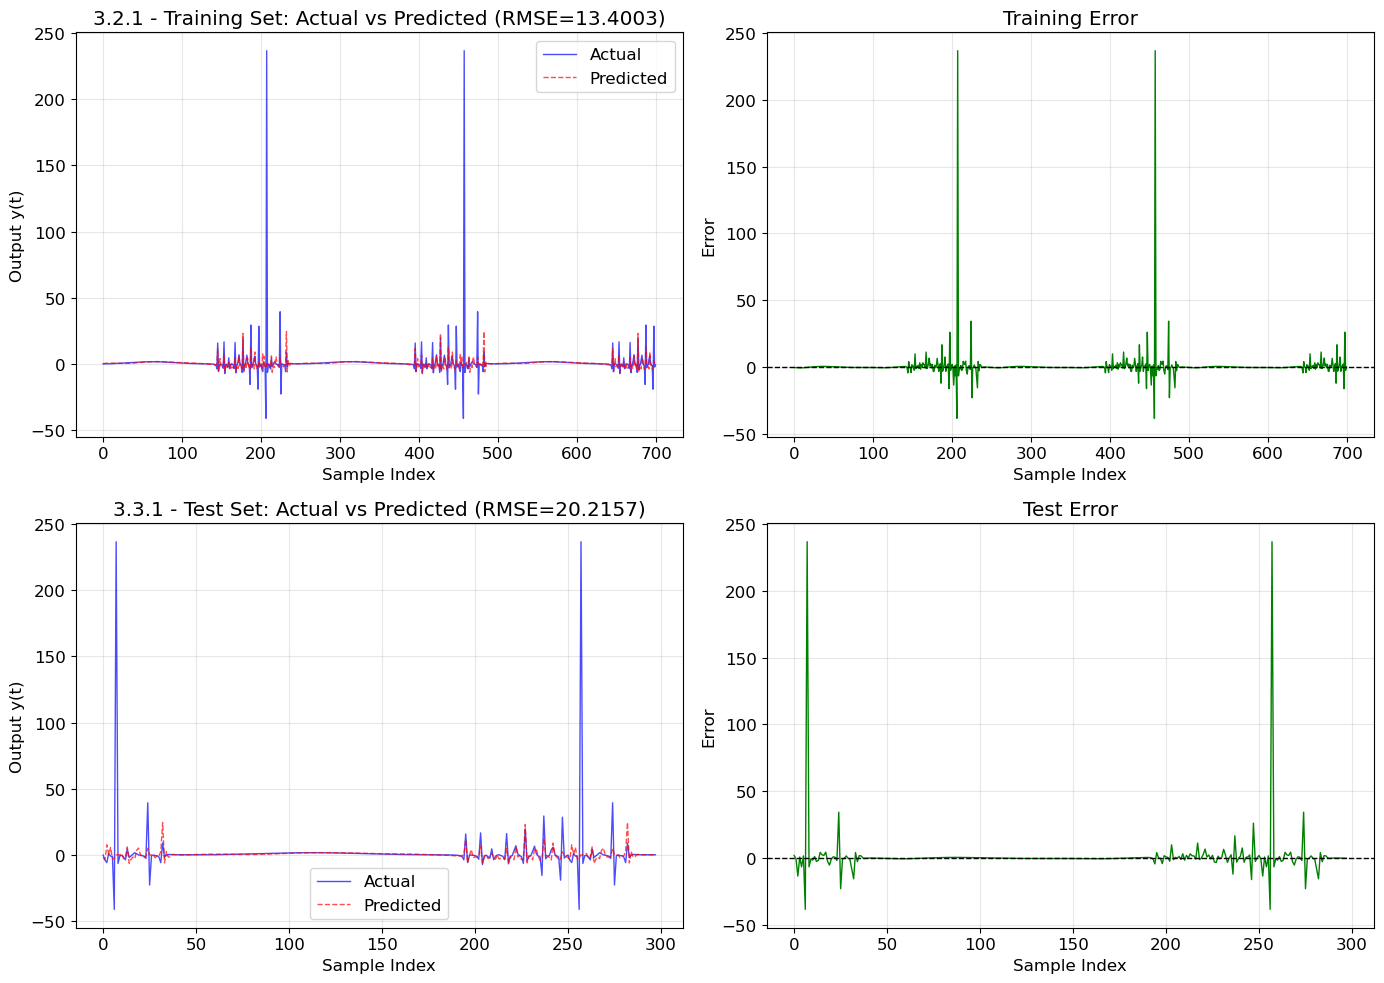


3.3.1 - Error Analysis
Maximum absolute error: 236.7103
Location (sample index): 257
Actual value at max error: 236.7103
Predicted value at max error: 0.0000

Error Statistics:
  Mean Error: 1.340947
  Std Error: 20.171201
  Max Error: 236.710282
  Min Error: -38.274682

✓ Plot saved: plots/Q6_P3_actual_vs_predicted.png


In [187]:
# =====================================================
# 3.2.1 - Training Set: Predicted vs Actual
# 3.3.1 - Test Set: Predicted vs Actual with Error Analysis
# =====================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 3.2.1 - Training set
axes[0, 0].plot(Y_train, 'b-', linewidth=1, alpha=0.7, label='Actual')
axes[0, 0].plot(Y_train_pred_lls, 'r--', linewidth=1, alpha=0.7, label='Predicted')
axes[0, 0].set_xlabel('Sample Index')
axes[0, 0].set_ylabel('Output y(t)')
axes[0, 0].set_title(f'3.2.1 - Training Set: Actual vs Predicted (RMSE={train_rmse_lls:.4f})')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Training error
train_error_lls = Y_train - Y_train_pred_lls
axes[0, 1].plot(train_error_lls, 'g-', linewidth=1)
axes[0, 1].axhline(y=0, color='k', linestyle='--', linewidth=1)
axes[0, 1].set_xlabel('Sample Index')
axes[0, 1].set_ylabel('Error')
axes[0, 1].set_title('Training Error')
axes[0, 1].grid(True, alpha=0.3)

# 3.3.1 - Test set
axes[1, 0].plot(Y_test, 'b-', linewidth=1, alpha=0.7, label='Actual')
axes[1, 0].plot(Y_test_pred_lls, 'r--', linewidth=1, alpha=0.7, label='Predicted')
axes[1, 0].set_xlabel('Sample Index')
axes[1, 0].set_ylabel('Output y(t)')
axes[1, 0].set_title(f'3.3.1 - Test Set: Actual vs Predicted (RMSE={test_rmse_lls:.4f})')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Test error
test_error_lls = Y_test - Y_test_pred_lls
axes[1, 1].plot(test_error_lls, 'g-', linewidth=1)
axes[1, 1].axhline(y=0, color='k', linestyle='--', linewidth=1)
axes[1, 1].set_xlabel('Sample Index')
axes[1, 1].set_ylabel('Error')
axes[1, 1].set_title('Test Error')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/Q6_P3_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

# Error analysis for 3.3.1
print("\n" + "="*60)
print("3.3.1 - Error Analysis")
print("="*60)
max_error_idx = np.argmax(np.abs(test_error_lls))
print(f"Maximum absolute error: {np.abs(test_error_lls[max_error_idx]):.4f}")
print(f"Location (sample index): {max_error_idx}")
print(f"Actual value at max error: {Y_test[max_error_idx]:.4f}")
print(f"Predicted value at max error: {Y_test_pred_lls[max_error_idx]:.4f}")
print(f"\nError Statistics:")
print(f"  Mean Error: {np.mean(test_error_lls):.6f}")
print(f"  Std Error: {np.std(test_error_lls):.6f}")
print(f"  Max Error: {np.max(test_error_lls):.6f}")
print(f"  Min Error: {np.min(test_error_lls):.6f}")

print("\n✓ Plot saved: plots/Q6_P3_actual_vs_predicted.png")


3.5.1 - Training with Different K Values (Fixed σ)
Using fixed σ = 6.9035

K =  10: Train RMSE = 13.5843, Test RMSE = 20.3168, Test R² = 0.0022
K =  20: Train RMSE = 13.4287, Test RMSE = 20.2305, Test R² = 0.0107
K =  50: Train RMSE = 13.1259, Test RMSE = 19.9704, Test R² = 0.0360
K = 100: Train RMSE = 13.0393, Test RMSE = 19.9053, Test R² = 0.0423
K = 200: Train RMSE = 12.9622, Test RMSE = 19.8001, Test R² = 0.0523

✓ Best K = 200 (Test RMSE = 19.8001)


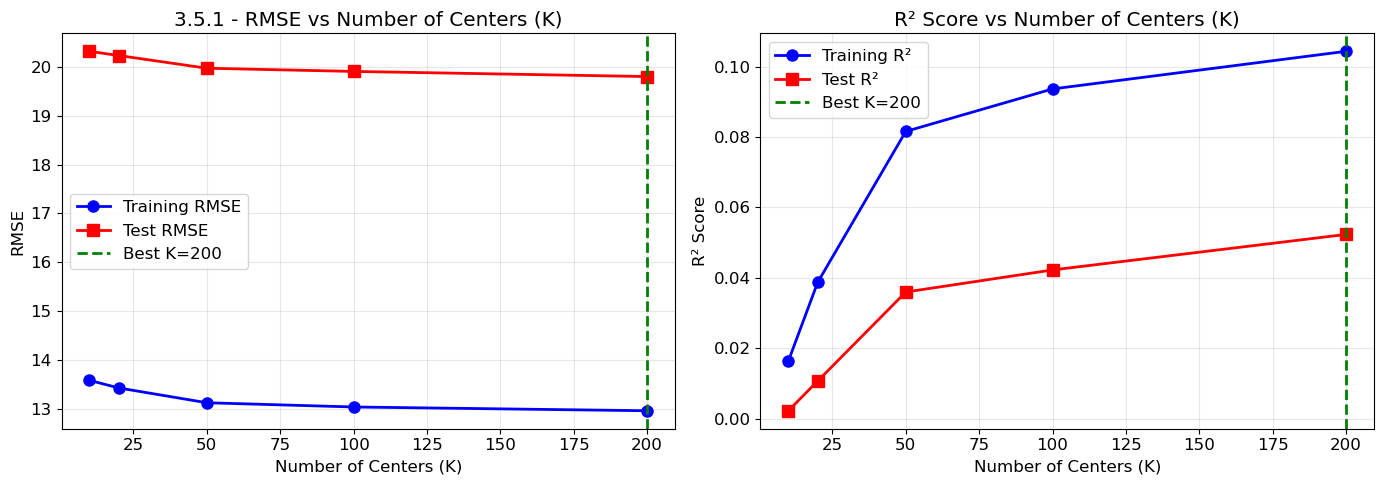


✓ Plot saved: plots/Q6_P3_K_effect.png


In [188]:
# =====================================================
# 3.5.1 - Effect of K (Number of Centers) on Performance
# =====================================================

K_values = [10, 20, 50, 100, 200]
train_rmse_K = []
test_rmse_K = []
train_r2_K = []
test_r2_K = []

print("="*60)
print("3.5.1 - Training with Different K Values (Fixed σ)")
print("="*60)

# Use fixed sigma (calculated from first model)
fixed_sigma = model_lls.sigma
print(f"Using fixed σ = {fixed_sigma:.4f}\n")

for K in K_values:
    np.random.seed(42)
    model = RBFNN_LLS(n_centers=K, sigma=fixed_sigma)
    model.fit(X_train, Y_train)
    
    train_rmse_K.append(model.rmse(X_train, Y_train))
    test_rmse_K.append(model.rmse(X_test, Y_test))
    train_r2_K.append(model.r2_score(X_train, Y_train))
    test_r2_K.append(model.r2_score(X_test, Y_test))
    
    print(f"K = {K:3d}: Train RMSE = {train_rmse_K[-1]:.4f}, Test RMSE = {test_rmse_K[-1]:.4f}, Test R² = {test_r2_K[-1]:.4f}")

# Find best K
best_K_idx = np.argmin(test_rmse_K)
best_K = K_values[best_K_idx]
print(f"\n✓ Best K = {best_K} (Test RMSE = {test_rmse_K[best_K_idx]:.4f})")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_values, train_rmse_K, 'bo-', linewidth=2, markersize=8, label='Training RMSE')
axes[0].plot(K_values, test_rmse_K, 'rs-', linewidth=2, markersize=8, label='Test RMSE')
axes[0].axvline(x=best_K, color='g', linestyle='--', linewidth=2, label=f'Best K={best_K}')
axes[0].set_xlabel('Number of Centers (K)')
axes[0].set_ylabel('RMSE')
axes[0].set_title('3.5.1 - RMSE vs Number of Centers (K)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_values, train_r2_K, 'bo-', linewidth=2, markersize=8, label='Training R²')
axes[1].plot(K_values, test_r2_K, 'rs-', linewidth=2, markersize=8, label='Test R²')
axes[1].axvline(x=best_K, color='g', linestyle='--', linewidth=2, label=f'Best K={best_K}')
axes[1].set_xlabel('Number of Centers (K)')
axes[1].set_ylabel('R² Score')
axes[1].set_title('R² Score vs Number of Centers (K)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/Q6_P3_K_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Plot saved: plots/Q6_P3_K_effect.png")


3.7.1 - Training with Different σ Values (Fixed K=200)
σ =  0.5: Train RMSE = 13.1053, Test RMSE = 19.8402, Test R² = 0.0485
σ =  1.0: Train RMSE = 12.8937, Test RMSE = 19.5891, Test R² = 0.0724
σ =  5.0: Train RMSE = 12.8776, Test RMSE = 19.6822, Test R² = 0.0636
σ =  7.0: Train RMSE = 12.9631, Test RMSE = 19.8009, Test R² = 0.0523
σ = 10.0: Train RMSE = 10.1571, Test RMSE = 13.7731, Test R² = 0.5415

✓ Best σ = 10 (Test RMSE = 13.7731)


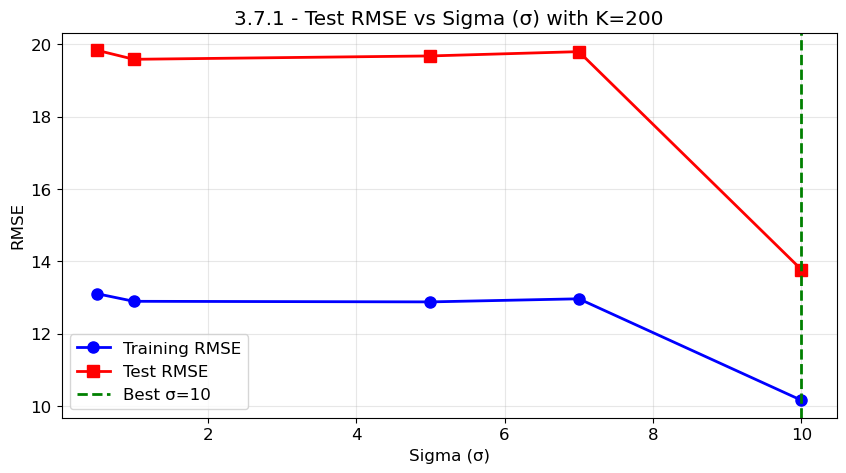


✓ Plot saved: plots/Q6_P3_sigma_effect.png


In [189]:
# =====================================================
# 3.7.1 - Effect of Sigma (σ) on Performance
# =====================================================

sigma_values = [0.5, 1, 5, 7, 10]
train_rmse_sigma = []
test_rmse_sigma = []
train_r2_sigma = []
test_r2_sigma = []

print("="*60)
print(f"3.7.1 - Training with Different σ Values (Fixed K={best_K})")
print("="*60)

for sigma in sigma_values:
    np.random.seed(42)
    model = RBFNN_LLS(n_centers=best_K, sigma=sigma)
    model.fit(X_train, Y_train)
    
    train_rmse_sigma.append(model.rmse(X_train, Y_train))
    test_rmse_sigma.append(model.rmse(X_test, Y_test))
    train_r2_sigma.append(model.r2_score(X_train, Y_train))
    test_r2_sigma.append(model.r2_score(X_test, Y_test))
    
    print(f"σ = {sigma:4.1f}: Train RMSE = {train_rmse_sigma[-1]:.4f}, Test RMSE = {test_rmse_sigma[-1]:.4f}, Test R² = {test_r2_sigma[-1]:.4f}")

# Find best sigma
best_sigma_idx = np.argmin(test_rmse_sigma)
best_sigma = sigma_values[best_sigma_idx]
print(f"\n✓ Best σ = {best_sigma} (Test RMSE = {test_rmse_sigma[best_sigma_idx]:.4f})")

# Plot RMSE vs Sigma
plt.figure(figsize=(10, 5))
plt.plot(sigma_values, train_rmse_sigma, 'bo-', linewidth=2, markersize=8, label='Training RMSE')
plt.plot(sigma_values, test_rmse_sigma, 'rs-', linewidth=2, markersize=8, label='Test RMSE')
plt.axvline(x=best_sigma, color='g', linestyle='--', linewidth=2, label=f'Best σ={best_sigma}')
plt.xlabel('Sigma (σ)')
plt.ylabel('RMSE')
plt.title(f'3.7.1 - Test RMSE vs Sigma (σ) with K={best_K}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('plots/Q6_P3_sigma_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Plot saved: plots/Q6_P3_sigma_effect.png")


Best Model: K=200, σ=10
Test RMSE: 13.773054
Test R²:   0.541462


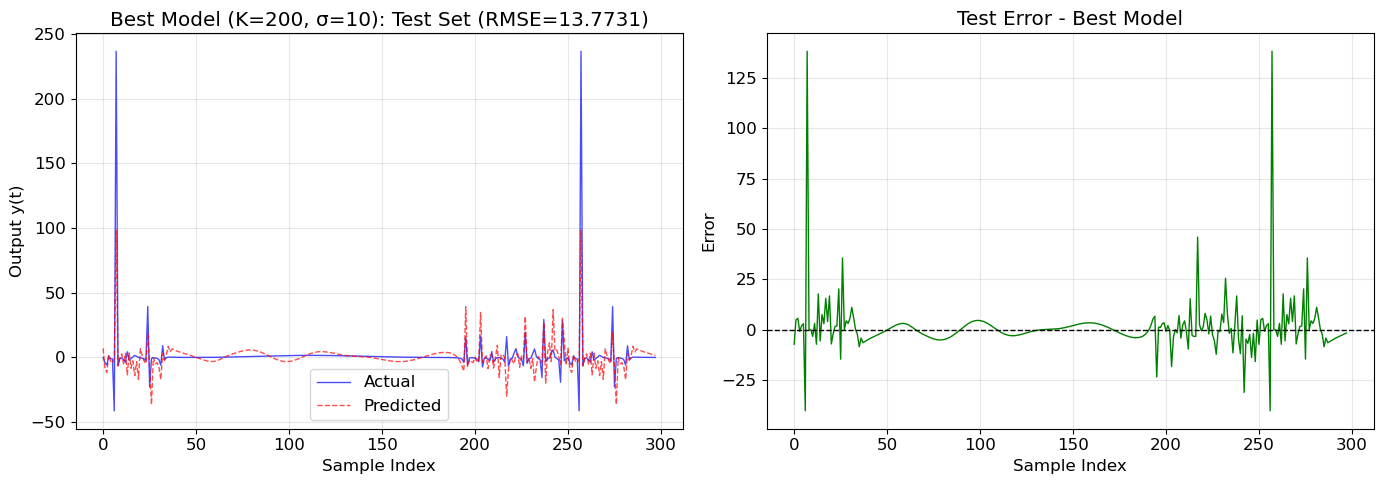


✓ Plot saved: plots/Q6_P3_best_model.png


In [190]:
# =====================================================
# Best Model Evaluation (Best K and Best σ)
# =====================================================

print("="*60)
print(f"Best Model: K={best_K}, σ={best_sigma}")
print("="*60)

np.random.seed(42)
best_model = RBFNN_LLS(n_centers=best_K, sigma=best_sigma)
best_model.fit(X_train, Y_train)

Y_test_pred_best = best_model.predict(X_test)
best_test_rmse = best_model.rmse(X_test, Y_test)
best_test_r2 = best_model.r2_score(X_test, Y_test)

print(f"Test RMSE: {best_test_rmse:.6f}")
print(f"Test R²:   {best_test_r2:.6f}")

# Plot actual vs predicted for best model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(Y_test, 'b-', linewidth=1, alpha=0.7, label='Actual')
axes[0].plot(Y_test_pred_best, 'r--', linewidth=1, alpha=0.7, label='Predicted')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Output y(t)')
axes[0].set_title(f'Best Model (K={best_K}, σ={best_sigma}): Test Set (RMSE={best_test_rmse:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Error plot
error_best = Y_test - Y_test_pred_best
axes[1].plot(error_best, 'g-', linewidth=1)
axes[1].axhline(y=0, color='k', linestyle='--', linewidth=1)
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Error')
axes[1].set_title('Test Error - Best Model')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/Q6_P3_best_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Plot saved: plots/Q6_P3_best_model.png")


In [191]:
# Part 3 completed


## Part 4


In [192]:
# =====================================================
# Part 4: RBFNN with L2 Regularization
# =====================================================

class RBFNN_L2:
    """
    RBFNN with L2 Regularization (Ridge Regression).
    Solves: (Φᵀ Φ + λI) α = Φᵀ Y
    """
    
    def __init__(self, n_centers=25, sigma=None, lambda_reg=0.0):
        self.n_centers = n_centers
        self.sigma = sigma
        self.lambda_reg = lambda_reg  # Regularization coefficient
        self.centers = None
        self.weights = None
        
    def _compute_phi_matrix(self, X):
        """Compute the Φ matrix"""
        n_samples = X.shape[0]
        Phi = np.zeros((n_samples, self.n_centers))
        
        for j in range(self.n_centers):
            diff = X - self.centers[j]
            dist_squared = np.sum(diff**2, axis=1)
            Phi[:, j] = np.exp(-dist_squared / (self.sigma**2))
        
        return Phi
    
    def fit(self, X, y):
        """Train RBFNN with L2 Regularization."""
        n_samples = X.shape[0]
        
        # Select K centers randomly
        random_indices = np.random.choice(n_samples, self.n_centers, replace=False)
        self.centers = X[random_indices]
        
        # Calculate sigma if not specified
        if self.sigma is None:
            distances = []
            for i in range(self.n_centers):
                for j in range(i+1, self.n_centers):
                    d = np.sqrt(np.sum((self.centers[i] - self.centers[j])**2))
                    distances.append(d)
            self.sigma = np.mean(distances)
        
        # Build Φ matrix
        Phi = self._compute_phi_matrix(X)
        
        # Solve with L2 regularization: (Φᵀ Φ + λI) α = Φᵀ y
        PhiT_Phi = Phi.T @ Phi
        regularization = self.lambda_reg * np.eye(self.n_centers)
        PhiT_y = Phi.T @ y
        
        # Use lstsq for numerical stability (handles near-singular matrices)
        A = PhiT_Phi + regularization
        self.weights = np.linalg.lstsq(A, PhiT_y, rcond=None)[0]
        
        return self
    
    def predict(self, X):
        Phi = self._compute_phi_matrix(X)
        return Phi @ self.weights
    
    def rmse(self, X, y):
        y_pred = self.predict(X)
        return np.sqrt(np.mean((y - y_pred)**2))
    
    def r2_score(self, X, y):
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        return 1 - (ss_res / ss_tot)

print("✓ RBFNN_L2 class with L2 Regularization defined!")


✓ RBFNN_L2 class with L2 Regularization defined!


In [193]:
# =====================================================
# 1.4.1 - Test with Different Lambda Values
# =====================================================

# Use large K to demonstrate regularization effect
K_large = 200
sigma_fixed = 10.0  # Best sigma from Part 3
lambda_values = [0, 0.001, 0.01, 0.1, 1, 10]

results_lambda = []

print("="*70)
print(f"1.4.1 - RBFNN with L2 Regularization (K={K_large}, σ={sigma_fixed})")
print("="*70)
print(f"{'Lambda':>10} {'Train RMSE':>15} {'Test RMSE':>15} {'Train R²':>12} {'Test R²':>12}")
print("-"*70)

for lam in lambda_values:
    np.random.seed(42)
    model = RBFNN_L2(n_centers=K_large, sigma=sigma_fixed, lambda_reg=lam)
    model.fit(X_train, Y_train)
    
    train_rmse = model.rmse(X_train, Y_train)
    test_rmse = model.rmse(X_test, Y_test)
    train_r2 = model.r2_score(X_train, Y_train)
    test_r2 = model.r2_score(X_test, Y_test)
    
    results_lambda.append({
        'lambda': lam,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_r2': train_r2,
        'test_r2': test_r2
    })
    
    print(f"{lam:>10} {train_rmse:>15.4f} {test_rmse:>15.4f} {train_r2:>12.4f} {test_r2:>12.4f}")

# Find best lambda
best_lambda_idx = np.argmin([r['test_rmse'] for r in results_lambda])
best_lambda = results_lambda[best_lambda_idx]['lambda']
print("-"*70)
print(f"Best λ = {best_lambda} (Test RMSE = {results_lambda[best_lambda_idx]['test_rmse']:.4f})")


1.4.1 - RBFNN with L2 Regularization (K=200, σ=10.0)
    Lambda      Train RMSE       Test RMSE     Train R²      Test R²
----------------------------------------------------------------------


         0         13.2038         20.0705       0.0707       0.0263
     0.001         13.2928         20.1605       0.0581       0.0175
      0.01         13.3005         20.1646       0.0570       0.0171
       0.1         13.3095         20.1668       0.0557       0.0169
         1         13.3231         20.1712       0.0538       0.0165
        10         13.4244         20.2314       0.0394       0.0106
----------------------------------------------------------------------
Best λ = 0 (Test RMSE = 20.0705)


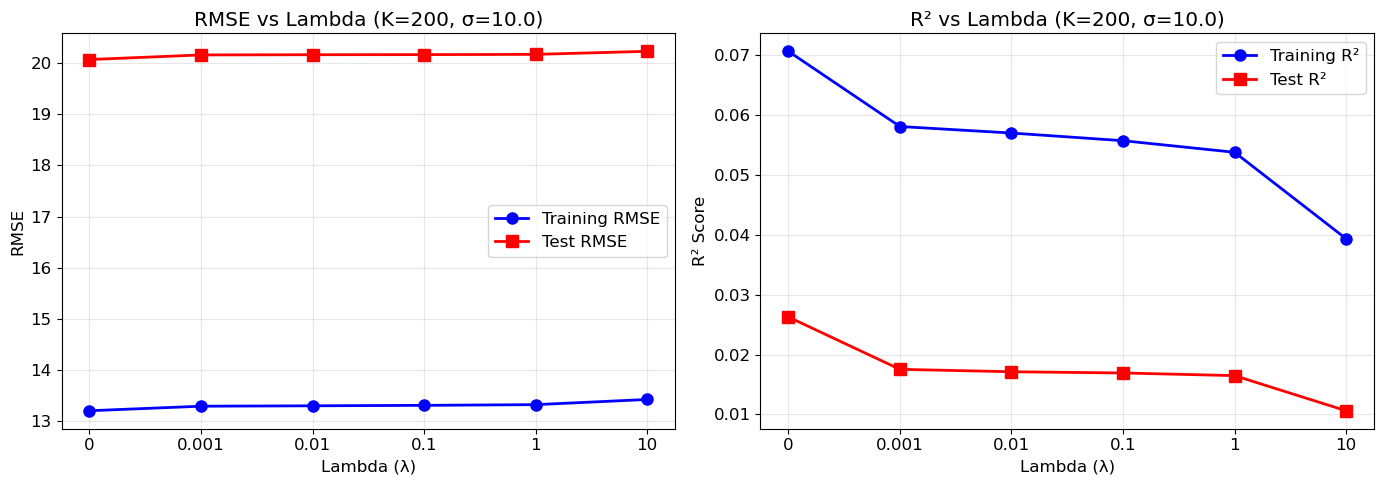

✓ Plot saved: plots/Q6_P4_lambda_effect.png


In [194]:
# Plot Lambda Effect
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lambda_plot = [r['lambda'] for r in results_lambda]
train_rmse_plot = [r['train_rmse'] for r in results_lambda]
test_rmse_plot = [r['test_rmse'] for r in results_lambda]
train_r2_plot = [r['train_r2'] for r in results_lambda]
test_r2_plot = [r['test_r2'] for r in results_lambda]

# Use log scale for lambda (handle 0)
lambda_labels = ['0', '0.001', '0.01', '0.1', '1', '10']

axes[0].plot(range(len(lambda_values)), train_rmse_plot, 'bo-', linewidth=2, markersize=8, label='Training RMSE')
axes[0].plot(range(len(lambda_values)), test_rmse_plot, 'rs-', linewidth=2, markersize=8, label='Test RMSE')
axes[0].set_xticks(range(len(lambda_values)))
axes[0].set_xticklabels(lambda_labels)
axes[0].set_xlabel('Lambda (λ)')
axes[0].set_ylabel('RMSE')
axes[0].set_title(f'RMSE vs Lambda (K={K_large}, σ={sigma_fixed})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(len(lambda_values)), train_r2_plot, 'bo-', linewidth=2, markersize=8, label='Training R²')
axes[1].plot(range(len(lambda_values)), test_r2_plot, 'rs-', linewidth=2, markersize=8, label='Test R²')
axes[1].set_xticks(range(len(lambda_values)))
axes[1].set_xticklabels(lambda_labels)
axes[1].set_xlabel('Lambda (λ)')
axes[1].set_ylabel('R² Score')
axes[1].set_title(f'R² vs Lambda (K={K_large}, σ={sigma_fixed})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/Q6_P4_lambda_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved: plots/Q6_P4_lambda_effect.png")


Comparison: With vs Without Regularization

Without Regularization (λ=0):
  Test RMSE: 20.0705
  Test R²:   0.0263

With Regularization (λ=0):
  Test RMSE: 20.0705
  Test R²:   0.0263


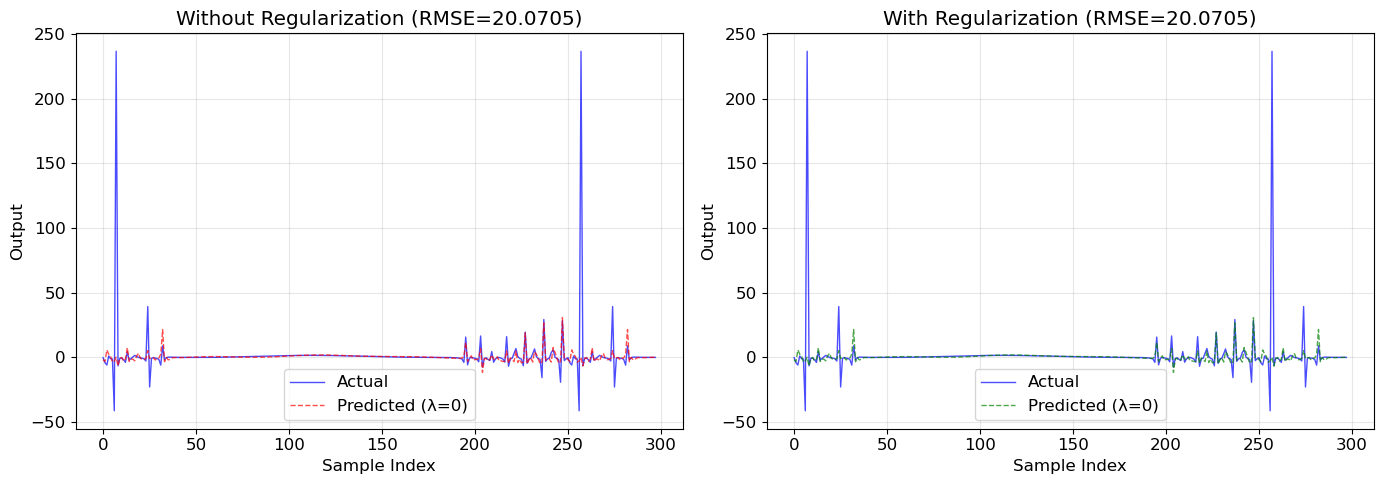

✓ Plot saved: plots/Q6_P4_regularization_comparison.png


In [195]:
# =====================================================
# Comparison: With and Without Regularization
# =====================================================

print("="*70)
print("Comparison: With vs Without Regularization")
print("="*70)

# Without regularization (λ = 0)
np.random.seed(42)
model_no_reg = RBFNN_L2(n_centers=K_large, sigma=sigma_fixed, lambda_reg=0)
model_no_reg.fit(X_train, Y_train)
pred_no_reg = model_no_reg.predict(X_test)

# With best regularization
np.random.seed(42)
model_with_reg = RBFNN_L2(n_centers=K_large, sigma=sigma_fixed, lambda_reg=best_lambda)
model_with_reg.fit(X_train, Y_train)
pred_with_reg = model_with_reg.predict(X_test)

print(f"\nWithout Regularization (λ=0):")
print(f"  Test RMSE: {model_no_reg.rmse(X_test, Y_test):.4f}")
print(f"  Test R²:   {model_no_reg.r2_score(X_test, Y_test):.4f}")

print(f"\nWith Regularization (λ={best_lambda}):")
print(f"  Test RMSE: {model_with_reg.rmse(X_test, Y_test):.4f}")
print(f"  Test R²:   {model_with_reg.r2_score(X_test, Y_test):.4f}")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(Y_test, 'b-', linewidth=1, alpha=0.7, label='Actual')
axes[0].plot(pred_no_reg, 'r--', linewidth=1, alpha=0.7, label='Predicted (λ=0)')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Output')
axes[0].set_title(f'Without Regularization (RMSE={model_no_reg.rmse(X_test, Y_test):.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(Y_test, 'b-', linewidth=1, alpha=0.7, label='Actual')
axes[1].plot(pred_with_reg, 'g--', linewidth=1, alpha=0.7, label=f'Predicted (λ={best_lambda})')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Output')
axes[1].set_title(f'With Regularization (RMSE={model_with_reg.rmse(X_test, Y_test):.4f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/Q6_P4_regularization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved: plots/Q6_P4_regularization_comparison.png")


In [196]:
# Part 4 completed


## Part 5


In [197]:
# =====================================================
# 1.5.1 - RBFNN with K-Means Centers (Fixed Sigma)
# =====================================================

class RBFNN_KMeans:
    """RBFNN with K-Means clustering for center selection."""
    
    def __init__(self, n_centers=25, sigma=None):
        self.n_centers = n_centers
        self.sigma = sigma
        self.centers = None
        self.weights = None
        
    def _compute_phi_matrix(self, X):
        n_samples = X.shape[0]
        Phi = np.zeros((n_samples, self.n_centers))
        for j in range(self.n_centers):
            diff = X - self.centers[j]
            dist_squared = np.sum(diff**2, axis=1)
            Phi[:, j] = np.exp(-dist_squared / (self.sigma**2))
        return Phi
    
    def fit(self, X, y):
        # Use K-Means to find centers
        kmeans = KMeans(n_clusters=self.n_centers, random_state=42, n_init=10)
        kmeans.fit(X)
        self.centers = kmeans.cluster_centers_
        
        # Calculate sigma if not specified (average distance between centers)
        if self.sigma is None:
            distances = []
            for i in range(self.n_centers):
                for j in range(i+1, self.n_centers):
                    d = np.sqrt(np.sum((self.centers[i] - self.centers[j])**2))
                    distances.append(d)
            self.sigma = np.mean(distances)
        
        # Build Φ matrix and solve
        Phi = self._compute_phi_matrix(X)
        self.weights = np.linalg.lstsq(Phi, y, rcond=None)[0]
        return self
    
    def predict(self, X):
        Phi = self._compute_phi_matrix(X)
        return Phi @ self.weights
    
    def rmse(self, X, y):
        y_pred = self.predict(X)
        return np.sqrt(np.mean((y - y_pred)**2))
    
    def r2_score(self, X, y):
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        return 1 - (ss_res / ss_tot)

# Test with K-Means centers
K_test = 50  # K > 10
model_kmeans = RBFNN_KMeans(n_centers=K_test, sigma=None)
model_kmeans.fit(X_train, Y_train)

Y_test_pred_kmeans = model_kmeans.predict(X_test)
kmeans_test_rmse = model_kmeans.rmse(X_test, Y_test)
kmeans_test_r2 = model_kmeans.r2_score(X_test, Y_test)

# Compare with random centers (same K and sigma)
np.random.seed(42)
model_random = RBFNN_LLS(n_centers=K_test, sigma=model_kmeans.sigma)
model_random.fit(X_train, Y_train)
random_test_rmse = model_random.rmse(X_test, Y_test)
random_test_r2 = model_random.r2_score(X_test, Y_test)

print("="*60)
print(f"1.5.1 - K-Means vs Random Centers (K={K_test})")
print("="*60)
print(f"Sigma used: {model_kmeans.sigma:.4f}")
print(f"\n{'Method':<20} {'Test RMSE':>15} {'Test R²':>15}")
print("-"*50)
print(f"{'K-Means Centers':<20} {kmeans_test_rmse:>15.4f} {kmeans_test_r2:>15.4f}")
print(f"{'Random Centers':<20} {random_test_rmse:>15.4f} {random_test_r2:>15.4f}")


1.5.1 - K-Means vs Random Centers (K=50)
Sigma used: 35.6883

Method                     Test RMSE         Test R²
--------------------------------------------------
K-Means Centers               4.7129          0.9463
Random Centers                5.2655          0.9330


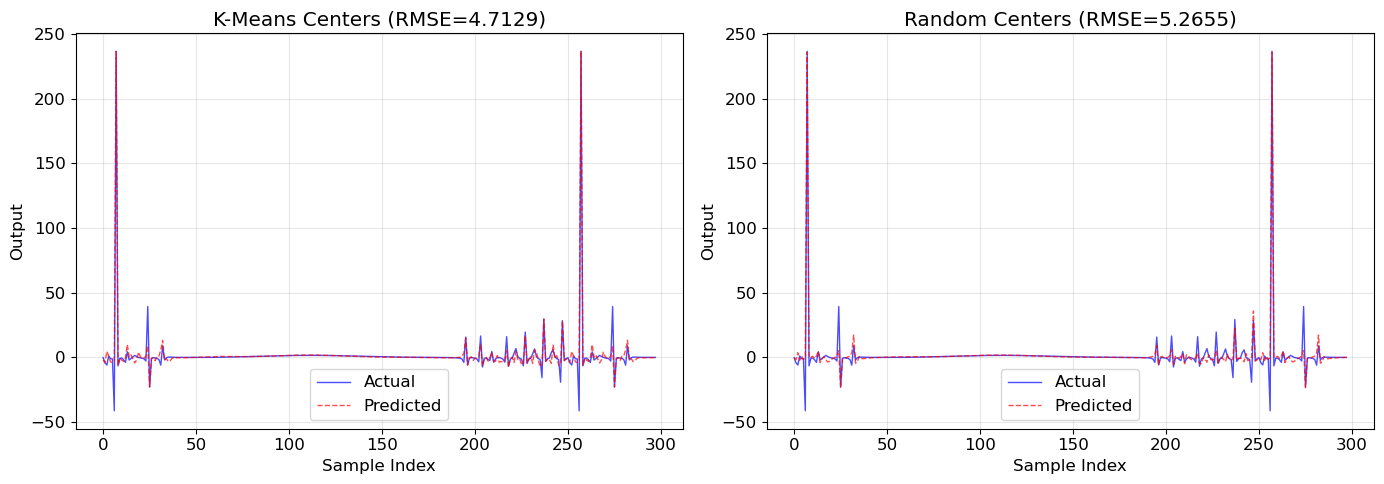

✓ Plot saved: plots/Q6_P5_kmeans_vs_random.png


In [198]:
# Plot K-Means results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means
axes[0].plot(Y_test, 'b-', linewidth=1, alpha=0.7, label='Actual')
axes[0].plot(Y_test_pred_kmeans, 'r--', linewidth=1, alpha=0.7, label='Predicted')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Output')
axes[0].set_title(f'K-Means Centers (RMSE={kmeans_test_rmse:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Random
Y_test_pred_random = model_random.predict(X_test)
axes[1].plot(Y_test, 'b-', linewidth=1, alpha=0.7, label='Actual')
axes[1].plot(Y_test_pred_random, 'r--', linewidth=1, alpha=0.7, label='Predicted')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Output')
axes[1].set_title(f'Random Centers (RMSE={random_test_rmse:.4f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/Q6_P5_kmeans_vs_random.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved: plots/Q6_P5_kmeans_vs_random.png")


In [199]:
# =====================================================
# 2.5.1 - Nearest-Neighbor Strategy for Sigma
# =====================================================

def compute_nn_sigmas(centers, p=2):
    """
    Compute sigma for each neuron using Nearest-Neighbor strategy.
    sigma_k = average distance to p nearest centers
    """
    n_centers = len(centers)
    sigmas = np.zeros(n_centers)
    
    for k in range(n_centers):
        # Compute distances to all other centers
        distances = []
        for j in range(n_centers):
            if j != k:  # Exclude self
                d = np.sqrt(np.sum((centers[k] - centers[j])**2))
                distances.append(d)
        
        # Sort distances ascending
        distances = np.sort(distances)
        
        # Take average of p nearest distances
        sigmas[k] = np.mean(distances[:p])
    
    return sigmas


class RBFNN_KMeans_NN:
    """RBFNN with K-Means centers and Nearest-Neighbor sigmas."""
    
    def __init__(self, n_centers=25, p=2):
        self.n_centers = n_centers
        self.p = p
        self.centers = None
        self.sigmas = None
        self.weights = None
        
    def _compute_phi_matrix(self, X):
        n_samples = X.shape[0]
        Phi = np.zeros((n_samples, self.n_centers))
        for j in range(self.n_centers):
            diff = X - self.centers[j]
            dist_squared = np.sum(diff**2, axis=1)
            Phi[:, j] = np.exp(-dist_squared / (self.sigmas[j]**2))
        return Phi
    
    def fit(self, X, y):
        # Use K-Means to find centers
        kmeans = KMeans(n_clusters=self.n_centers, random_state=42, n_init=10)
        kmeans.fit(X)
        self.centers = kmeans.cluster_centers_
        
        # Calculate sigmas using Nearest-Neighbor
        self.sigmas = compute_nn_sigmas(self.centers, self.p)
        
        # Build Φ matrix and solve
        Phi = self._compute_phi_matrix(X)
        self.weights = np.linalg.lstsq(Phi, y, rcond=None)[0]
        return self
    
    def predict(self, X):
        Phi = self._compute_phi_matrix(X)
        return Phi @ self.weights
    
    def rmse(self, X, y):
        y_pred = self.predict(X)
        return np.sqrt(np.mean((y - y_pred)**2))
    
    def r2_score(self, X, y):
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        return 1 - (ss_res / ss_tot)

# Train with Nearest-Neighbor sigmas (p=2)
p_value = 2
model_nn = RBFNN_KMeans_NN(n_centers=K_test, p=p_value)
model_nn.fit(X_train, Y_train)

nn_train_rmse = model_nn.rmse(X_train, Y_train)
nn_test_rmse = model_nn.rmse(X_test, Y_test)
nn_train_r2 = model_nn.r2_score(X_train, Y_train)
nn_test_r2 = model_nn.r2_score(X_test, Y_test)

print("="*60)
print(f"2.5.1 - Nearest-Neighbor Sigmas (K={K_test}, p={p_value})")
print("="*60)
print(f"Sigma range: [{model_nn.sigmas.min():.4f}, {model_nn.sigmas.max():.4f}]")
print(f"Sigma mean: {model_nn.sigmas.mean():.4f}")
print(f"\n{'Metric':<15} {'Training':>15} {'Test':>15}")
print("-"*45)
print(f"{'RMSE':<15} {nn_train_rmse:>15.4f} {nn_test_rmse:>15.4f}")
print(f"{'R²':<15} {nn_train_r2:>15.4f} {nn_test_r2:>15.4f}")

# Compare with fixed sigma
print(f"\nComparison with Fixed Sigma:")
print(f"Fixed σ Test RMSE:    {kmeans_test_rmse:.4f}")
print(f"NN σ (p=2) Test RMSE: {nn_test_rmse:.4f}")


2.5.1 - Nearest-Neighbor Sigmas (K=50, p=2)
Sigma range: [0.3945, 204.9958]
Sigma mean: 12.2770

Metric                 Training            Test
---------------------------------------------
RMSE                     2.5418          3.4270
R²                       0.9656          0.9716

Comparison with Fixed Sigma:
Fixed σ Test RMSE:    4.7129
NN σ (p=2) Test RMSE: 3.4270


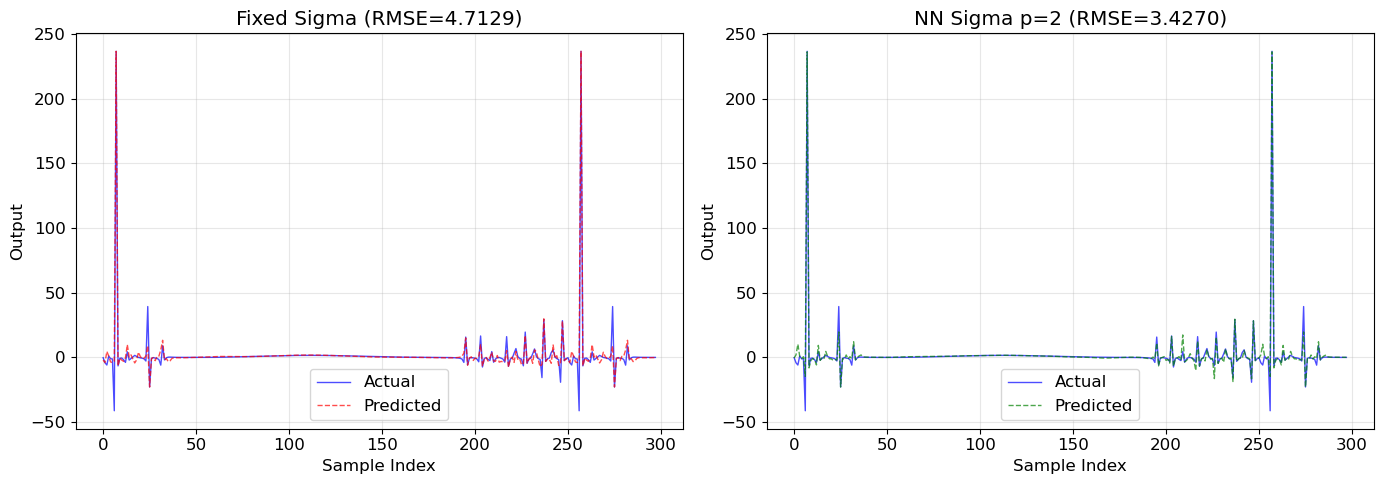

✓ Plot saved: plots/Q6_P5_fixed_vs_nn_sigma.png


In [200]:
# Plot NN sigma results
Y_test_pred_nn = model_nn.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fixed sigma (K-Means)
axes[0].plot(Y_test, 'b-', linewidth=1, alpha=0.7, label='Actual')
axes[0].plot(Y_test_pred_kmeans, 'r--', linewidth=1, alpha=0.7, label='Predicted')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Output')
axes[0].set_title(f'Fixed Sigma (RMSE={kmeans_test_rmse:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# NN sigma
axes[1].plot(Y_test, 'b-', linewidth=1, alpha=0.7, label='Actual')
axes[1].plot(Y_test_pred_nn, 'g--', linewidth=1, alpha=0.7, label='Predicted')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Output')
axes[1].set_title(f'NN Sigma p={p_value} (RMSE={nn_test_rmse:.4f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/Q6_P5_fixed_vs_nn_sigma.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved: plots/Q6_P5_fixed_vs_nn_sigma.png")


In [201]:
# Part 5 completed


## Part 6.2 - Adaptive RBFNN (M-RAN)


In [202]:
# =====================================================
# 1.1.2 - Growth Criteria Function
# =====================================================

def check_growth_criteria(x_n, y_n, y_pred, centers, epsilon, e_min):
    """
    Check if a new neuron should be added.
    """
    # Criterion 1: Novelty - x_n is far from all existing centers
    if len(centers) == 0:
        is_novel = True
        min_distance = float('inf')
    else:
        distances = [np.sqrt(np.sum((x_n - c)**2)) for c in centers]
        min_distance = min(distances)
        is_novel = min_distance > epsilon
    
    # Criterion 2: Error - prediction error is large
    error = abs(y_n - y_pred)
    is_error_large = error > e_min
    
    # Both criteria must be satisfied
    should_add = is_novel and is_error_large
    
    return should_add, is_novel, is_error_large, min_distance, error

# Test the function
epsilon_test = 1.0
e_min_test = 0.5
test_centers = np.array([[0, 0, 0], [1, 1, 1], [2, 2, 2]])
test_cases = [
    (np.array([0.1, 0.1, 0.1]), 5.0, 4.0),
    (np.array([0.1, 0.1, 0.1]), 5.0, 3.0),
    (np.array([5.0, 5.0, 5.0]), 5.0, 4.8),
    (np.array([5.0, 5.0, 5.0]), 5.0, 3.0),
]

print("="*70)
print("1.1.2 - Growth Criteria Test (ε=1.0, e_min=0.5)")
print("="*70)
print(f"{'x_n':<25} {'Error':>10} {'MinDist':>10} {'Novel':>8} {'ErrLrg':>8} {'Add':>6}")
print("-"*70)

for x_n, y_n, y_pred in test_cases:
    should_add, is_novel, is_error_large, min_dist, error = check_growth_criteria(
        x_n, y_n, y_pred, test_centers, epsilon_test, e_min_test
    )
    print(f"{str(x_n):<25} {error:>10.2f} {min_dist:>10.2f} {str(is_novel):>8} {str(is_error_large):>8} {str(should_add):>6}")


1.1.2 - Growth Criteria Test (ε=1.0, e_min=0.5)
x_n                            Error    MinDist    Novel   ErrLrg    Add
----------------------------------------------------------------------
[0.1 0.1 0.1]                   1.00       0.17    False     True  False
[0.1 0.1 0.1]                   2.00       0.17    False     True  False
[5. 5. 5.]                      0.20       5.20     True    False  False
[5. 5. 5.]                      2.00       5.20     True     True   True


In [203]:
# =====================================================
# 1.2.2 - Adaptive RBFNN with M-RAN Algorithm
# =====================================================

class AdaptiveRBFNN:
    def __init__(self, epsilon=1.0, e_min=0.1, kappa=0.8, eta=0.05, delta=0.1, M=60):
        self.epsilon = epsilon
        self.e_min = e_min
        self.kappa = kappa
        self.eta = eta
        self.delta = delta
        self.M = M
        self.centers = []
        self.sigmas = []
        self.weights = []
        self.pruning_counters = []
        self.neuron_count_history = []
        
    def _rbf(self, x, center, sigma):
        dist_sq = np.sum((x - center)**2)
        return np.exp(-dist_sq / (sigma**2 + 1e-10))
    
    def predict_single(self, x):
        if len(self.centers) == 0:
            return 0.0
        output = 0.0
        for k in range(len(self.centers)):
            phi = self._rbf(x, self.centers[k], self.sigmas[k])
            output += self.weights[k] * phi
        return output
    
    def predict(self, X):
        return np.array([self.predict_single(x) for x in X])
    
    def _check_growth(self, x, y, y_pred):
        if len(self.centers) == 0:
            is_novel = True
            min_dist = float('inf')
        else:
            distances = [np.sqrt(np.sum((x - c)**2)) for c in self.centers]
            min_dist = min(distances)
            is_novel = min_dist > self.epsilon
        error = abs(y - y_pred)
        is_error_large = error > self.e_min
        return is_novel and is_error_large, min_dist, error
    
    def _add_neuron(self, x, error, min_dist):
        self.centers.append(x.copy())
        self.weights.append(error)
        sigma = self.kappa * min_dist if min_dist != float('inf') else 1.0
        self.sigmas.append(max(sigma, 0.1))
        self.pruning_counters.append(0)
    
    def _update_weights(self, x, error):
        for k in range(len(self.centers)):
            phi = self._rbf(x, self.centers[k], self.sigmas[k])
            self.weights[k] += self.eta * error * phi
    
    def _prune_neurons(self, x):
        if len(self.centers) == 0:
            return
        contributions = [abs(self.weights[k] * self._rbf(x, self.centers[k], self.sigmas[k])) 
                        for k in range(len(self.centers))]
        max_contrib = max(contributions) if max(contributions) > 0 else 1e-10
        to_remove = []
        for k in range(len(self.centers)):
            r_k = contributions[k] / max_contrib
            if r_k < self.delta:
                self.pruning_counters[k] += 1
                if self.pruning_counters[k] > self.M:
                    to_remove.append(k)
            else:
                self.pruning_counters[k] = 0
        for k in sorted(to_remove, reverse=True):
            del self.centers[k]
            del self.sigmas[k]
            del self.weights[k]
            del self.pruning_counters[k]
    
    def fit(self, X, y, epochs=1):
        n_samples = len(X)
        for epoch in range(epochs):
            for i in range(n_samples):
                x_n, y_n = X[i], y[i]
                y_pred = self.predict_single(x_n)
                error = y_n - y_pred
                should_add, min_dist, _ = self._check_growth(x_n, y_n, y_pred)
                if should_add:
                    self._add_neuron(x_n, error, min_dist)
                else:
                    self._update_weights(x_n, error)
                    self._prune_neurons(x_n)
                self.neuron_count_history.append(len(self.centers))
        return self
    
    def rmse(self, X, y):
        y_pred = self.predict(X)
        return np.sqrt(np.mean((y - y_pred)**2))
    
    def r2_score(self, X, y):
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        return 1 - (ss_res / ss_tot)

print("✓ AdaptiveRBFNN class defined")


✓ AdaptiveRBFNN class defined


In [204]:
# =====================================================
# 2.2.2 - Train Adaptive RBFNN with Grid Search
# =====================================================

e_min_values = [0.05, 0.1, 0.15, 0.2]
epsilon_values = [0.5, 1.0, 2.0, 5.0]
kappa, eta, delta, M = 0.8, 0.05, 0.1, 60

best_model = None
best_test_rmse = float('inf')
best_params = {}
results_grid = []

print("="*70)
print("2.2.2 - Adaptive RBFNN Hyperparameter Search")
print("="*70)
print(f"Fixed: κ={kappa}, η={eta}, δ={delta}, M={M}")
print(f"Search: e_min ∈ {e_min_values}, ε ∈ {epsilon_values}")
print("-"*70)

for e_min in e_min_values:
    for eps in epsilon_values:
        model = AdaptiveRBFNN(epsilon=eps, e_min=e_min, kappa=kappa, eta=eta, delta=delta, M=M)
        model.fit(X_train, Y_train, epochs=1)
        train_rmse = model.rmse(X_train, Y_train)
        test_rmse = model.rmse(X_test, Y_test)
        n_neurons = len(model.centers)
        results_grid.append({'e_min': e_min, 'epsilon': eps, 'train_rmse': train_rmse, 
                            'test_rmse': test_rmse, 'n_neurons': n_neurons})
        if test_rmse < best_test_rmse:
            best_test_rmse = test_rmse
            best_model = model
            best_params = {'e_min': e_min, 'epsilon': eps}
        print(f"e_min={e_min:.2f}, ε={eps:.1f} -> Neurons={n_neurons:3d}, "
              f"Train RMSE={train_rmse:.4f}, Test RMSE={test_rmse:.4f}")

print("-"*70)
print(f"Best: e_min={best_params['e_min']}, ε={best_params['epsilon']}")
print(f"Neurons: {len(best_model.centers)}, Test RMSE: {best_test_rmse:.4f}")


2.2.2 - Adaptive RBFNN Hyperparameter Search
Fixed: κ=0.8, η=0.05, δ=0.1, M=60
Search: e_min ∈ [0.05, 0.1, 0.15, 0.2], ε ∈ [0.5, 1.0, 2.0, 5.0]
----------------------------------------------------------------------
e_min=0.05, ε=0.5 -> Neurons= 48, Train RMSE=3.5203, Test RMSE=4.8708
e_min=0.05, ε=1.0 -> Neurons= 29, Train RMSE=4.0053, Test RMSE=5.3965
e_min=0.05, ε=2.0 -> Neurons= 22, Train RMSE=3.8229, Test RMSE=5.2390
e_min=0.05, ε=5.0 -> Neurons= 14, Train RMSE=5.5493, Test RMSE=6.5093
e_min=0.10, ε=0.5 -> Neurons= 49, Train RMSE=3.5136, Test RMSE=4.8668
e_min=0.10, ε=1.0 -> Neurons= 32, Train RMSE=4.0732, Test RMSE=5.5191
e_min=0.10, ε=2.0 -> Neurons= 22, Train RMSE=3.8868, Test RMSE=5.2756
e_min=0.10, ε=5.0 -> Neurons= 14, Train RMSE=5.5488, Test RMSE=6.5089
e_min=0.15, ε=0.5 -> Neurons= 47, Train RMSE=3.5043, Test RMSE=4.8615
e_min=0.15, ε=1.0 -> Neurons= 28, Train RMSE=4.2428, Test RMSE=5.6237
e_min=0.15, ε=2.0 -> Neurons= 21, Train RMSE=3.8473, Test RMSE=5.3003
e_min=0.15, ε=5

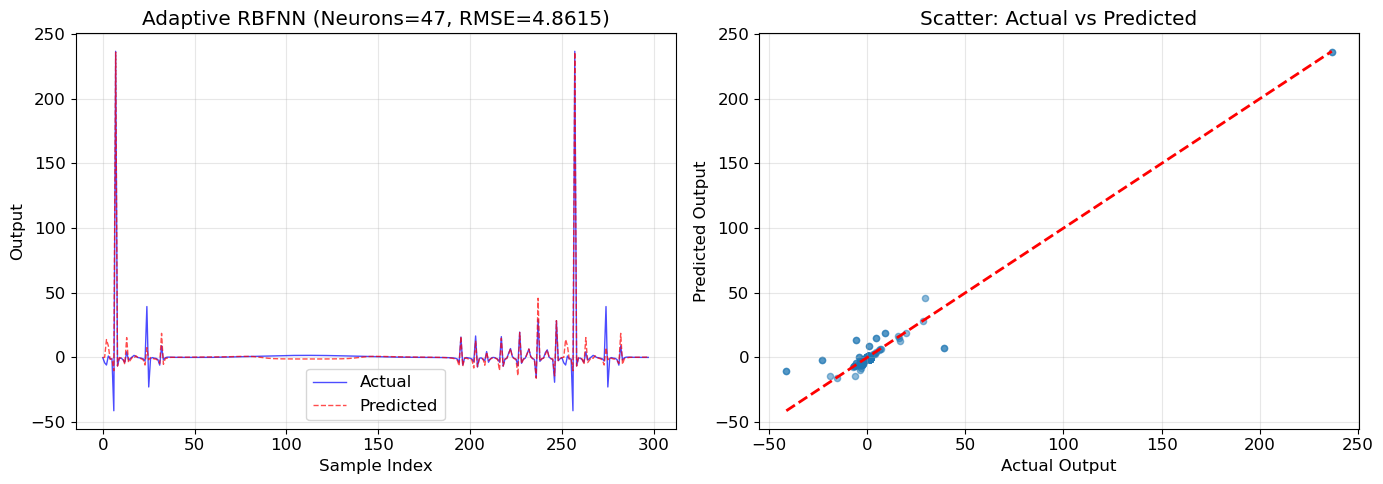

✓ Plot saved: plots/Q6_P6_adaptive_results.png


In [205]:
# Plot best model results
Y_test_pred_adaptive = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(Y_test, 'b-', linewidth=1, alpha=0.7, label='Actual')
axes[0].plot(Y_test_pred_adaptive, 'r--', linewidth=1, alpha=0.7, label='Predicted')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Output')
axes[0].set_title(f'Adaptive RBFNN (Neurons={len(best_model.centers)}, RMSE={best_test_rmse:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(Y_test, Y_test_pred_adaptive, alpha=0.5, s=20)
axes[1].plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', linewidth=2)
axes[1].set_xlabel('Actual Output')
axes[1].set_ylabel('Predicted Output')
axes[1].set_title('Scatter: Actual vs Predicted')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/Q6_P6_adaptive_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved: plots/Q6_P6_adaptive_results.png")


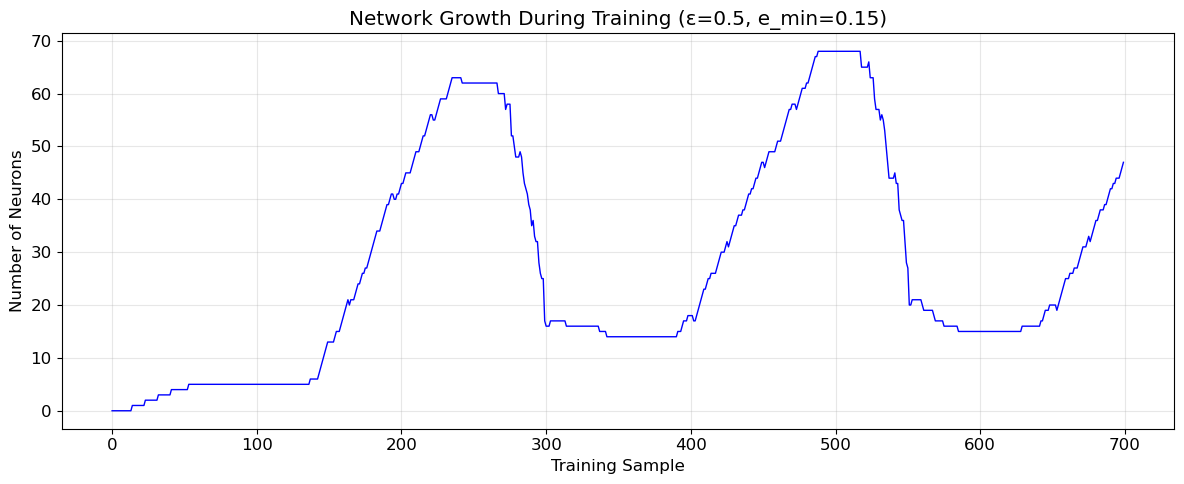

✓ Plot saved: plots/Q6_P6_neuron_growth.png


In [206]:
# 3.2.2 - Neuron Count History Plot
plt.figure(figsize=(12, 5))
plt.plot(best_model.neuron_count_history, 'b-', linewidth=1)
plt.xlabel('Training Sample')
plt.ylabel('Number of Neurons')
plt.title(f'Network Growth During Training (ε={best_params["epsilon"]}, e_min={best_params["e_min"]})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/Q6_P6_neuron_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved: plots/Q6_P6_neuron_growth.png")


In [207]:
# 4.2.2 - Comparison: Adaptive vs Static RBFNN
static_test_rmse = nn_test_rmse
static_n_neurons = K_test
K_adaptive = len(best_model.centers)
model_static_same = RBFNN_KMeans_NN(n_centers=K_adaptive, p=2)
model_static_same.fit(X_train, Y_train)
static_same_rmse = model_static_same.rmse(X_test, Y_test)

print("="*70)
print("4.2.2 - Comparison: Adaptive vs Static RBFNN")
print("="*70)
print(f"\n{'Model':<35} {'Neurons':>10} {'Test RMSE':>15}")
print("-"*60)
print(f"{'Adaptive RBFNN (M-RAN)':<35} {len(best_model.centers):>10} {best_test_rmse:>15.4f}")
print(f"{'Static RBFNN (K-Means+NN, K=50)':<35} {static_n_neurons:>10} {static_test_rmse:>15.4f}")
print(f"{'Static RBFNN (K-Means+NN, K=' + str(K_adaptive) + ')':<35} {K_adaptive:>10} {static_same_rmse:>15.4f}")
print("-"*60)
print(f"\nBest Adaptive Hyperparameters:")
print(f"  ε (epsilon) = {best_params['epsilon']}")
print(f"  e_min = {best_params['e_min']}")
print(f"  κ (kappa) = {kappa}")
print(f"  η (eta) = {eta}")
print(f"  δ (delta) = {delta}")
print(f"  M = {M}")


4.2.2 - Comparison: Adaptive vs Static RBFNN

Model                                  Neurons       Test RMSE
------------------------------------------------------------
Adaptive RBFNN (M-RAN)                      47          4.8615
Static RBFNN (K-Means+NN, K=50)             50          3.4270
Static RBFNN (K-Means+NN, K=47)             47          3.2540
------------------------------------------------------------

Best Adaptive Hyperparameters:
  ε (epsilon) = 0.5
  e_min = 0.15
  κ (kappa) = 0.8
  η (eta) = 0.05
  δ (delta) = 0.1
  M = 60


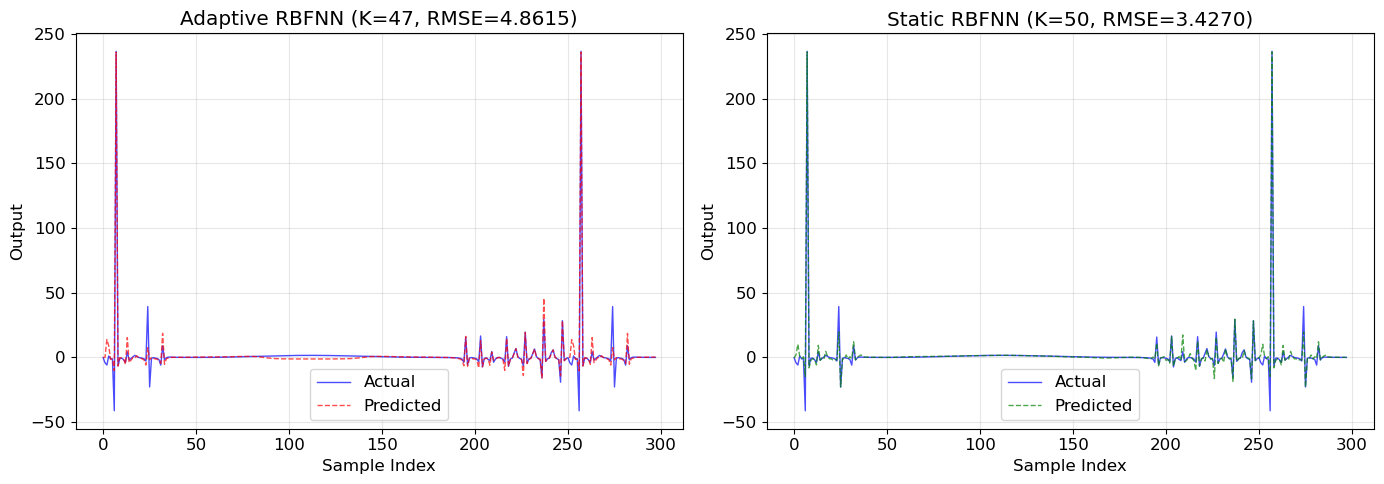

✓ Plot saved: plots/Q6_P6_adaptive_vs_static.png


In [208]:
# Comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(Y_test, 'b-', linewidth=1, alpha=0.7, label='Actual')
axes[0].plot(Y_test_pred_adaptive, 'r--', linewidth=1, alpha=0.7, label='Predicted')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Output')
axes[0].set_title(f'Adaptive RBFNN (K={len(best_model.centers)}, RMSE={best_test_rmse:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

Y_test_pred_static = model_nn.predict(X_test)
axes[1].plot(Y_test, 'b-', linewidth=1, alpha=0.7, label='Actual')
axes[1].plot(Y_test_pred_static, 'g--', linewidth=1, alpha=0.7, label='Predicted')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Output')
axes[1].set_title(f'Static RBFNN (K={static_n_neurons}, RMSE={static_test_rmse:.4f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/Q6_P6_adaptive_vs_static.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved: plots/Q6_P6_adaptive_vs_static.png")


# Question 7: Linear SVM and Parameter C Study


In [209]:
# Part A - Data Preparation
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, 
                             precision_recall_curve, auc)

data = load_breast_cancer()
X = data.data
y = data.target
RANDOM_STATE = 53

X_temp, X_test_svm, y_temp, y_test_svm = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
X_train_svm, X_val_svm, y_train_svm, y_val_svm = train_test_split(X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_svm)
X_val_scaled = scaler.transform(X_val_svm)
X_test_scaled = scaler.transform(X_test_svm)

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

print("="*60)
print("Part A - Data Preparation")
print("="*60)
print(f"Dataset: Breast Cancer Wisconsin (Diagnostic)")
print(f"Total samples: {len(X)}")
print(f"Features: {X.shape[1]}")
print(f"Classes: {data.target_names}")
print(f"\nSplit (random_state={RANDOM_STATE}):")
print(f"  Train: {len(X_train_svm)} samples ({len(X_train_svm)/len(X)*100:.0f}%)")
print(f"  Validation: {len(X_val_svm)} samples ({len(X_val_svm)/len(X)*100:.0f}%)")
print(f"  Test: {len(X_test_svm)} samples ({len(X_test_svm)/len(X)*100:.0f}%)")


Part A - Data Preparation
Dataset: Breast Cancer Wisconsin (Diagnostic)
Total samples: 569
Features: 30
Classes: ['malignant' 'benign']

Split (random_state=53):
  Train: 341 samples (60%)
  Validation: 114 samples (20%)
  Test: 114 samples (20%)


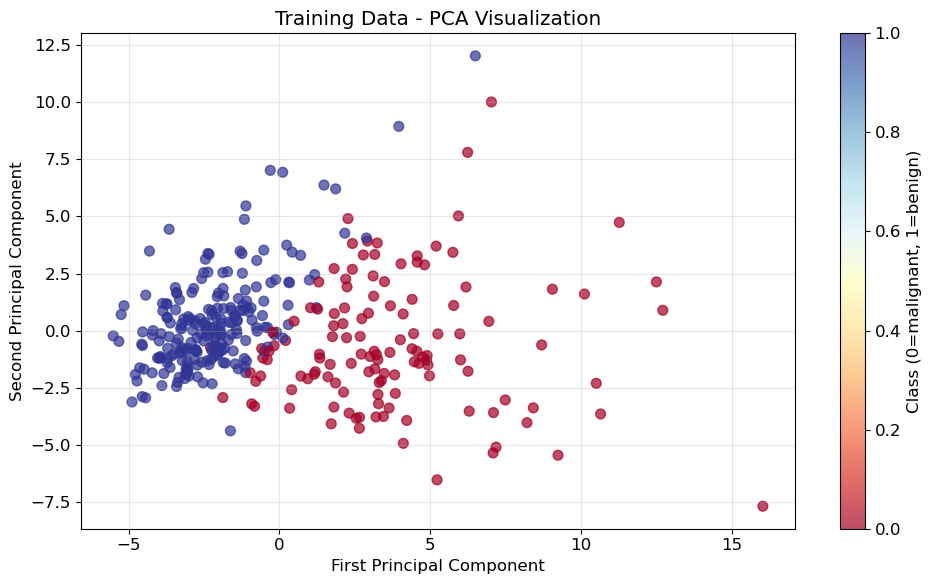

Plot saved: plots/Q7_pca_visualization.png


In [210]:
# PCA visualization
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train_svm, cmap='RdYlBu', alpha=0.7, s=50)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Training Data - PCA Visualization')
plt.colorbar(scatter, label='Class (0=malignant, 1=benign)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/Q7_pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: plots/Q7_pca_visualization.png")


In [211]:
# Part B - Train Linear SVM and Calculate Margin
def evaluate_svm(model, X_val, y_val, X_test, y_test):
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)
    y_val_proba = model.decision_function(X_val)
    y_test_proba = model.decision_function(X_test)
    metrics = {
        'val_acc': accuracy_score(y_val, y_val_pred),
        'val_prec': precision_score(y_val, y_val_pred),
        'val_rec': recall_score(y_val, y_val_pred),
        'val_f1': f1_score(y_val, y_val_pred),
        'val_auc': roc_auc_score(y_val, y_val_proba),
        'test_acc': accuracy_score(y_test, y_test_pred),
        'test_prec': precision_score(y_test, y_test_pred),
        'test_rec': recall_score(y_test, y_test_pred),
        'test_f1': f1_score(y_test, y_test_pred),
        'test_auc': roc_auc_score(y_test, y_test_proba),
    }
    return metrics

svm_model = SVC(kernel='linear', C=1.0)
svm_model.fit(X_train_scaled, y_train_svm)

w = svm_model.coef_[0]
w_norm = np.linalg.norm(w)
margin = 1 / w_norm
n_sv = svm_model.n_support_.sum()

metrics = evaluate_svm(svm_model, X_val_scaled, y_val_svm, X_test_scaled, y_test_svm)

print("="*60)
print("Part B - Training and Margin (C=1.0)")
print("="*60)
print(f"Number of support vectors: {n_sv}")
print(f"||w|| = {w_norm:.4f}")
print(f"Margin = 1/||w|| = {margin:.4f}")
print(f"\n{'Metric':<15} {'Validation':>15} {'Test':>15}")
print("-"*36)
print(f"{'Accuracy':<15} {metrics['val_acc']:>15.4f} {metrics['test_acc']:>15.4f}")
print(f"{'Precision':<15} {metrics['val_prec']:>15.4f} {metrics['test_prec']:>15.4f}")
print(f"{'Recall':<15} {metrics['val_rec']:>15.4f} {metrics['test_rec']:>15.4f}")
print(f"{'F1-Score':<15} {metrics['val_f1']:>15.4f} {metrics['test_f1']:>15.4f}")
print(f"{'ROC-AUC':<15} {metrics['val_auc']:>15.4f} {metrics['test_auc']:>15.4f}")


Part B - Training and Margin (C=1.0)
Number of support vectors: 26
||w|| = 2.5623
Margin = 1/||w|| = 0.3903

Metric               Validation            Test
------------------------------------
Accuracy                 0.9649          0.9912
Precision                0.9467          1.0000
Recall                   1.0000          0.9861
F1-Score                 0.9726          0.9930
ROC-AUC                  0.9931          1.0000


In [212]:
# Part C - Study C Parameter
C_values = [0.01, 0.1, 1, 10, 100]
results_C = []

print("="*70)
print("Part C - Study C Parameter")
print("="*70)
print(f"\n{'C':>6} {'#SV':>6} {'Margin':>8} {'Val Acc':>10} {'Val F1':>10} {'Test Acc':>10} {'Test F1':>10}")
print("-"*70)

for C in C_values:
    svm = SVC(kernel='linear', C=C)
    svm.fit(X_train_scaled, y_train_svm)
    w = svm.coef_[0]
    w_norm = np.linalg.norm(w)
    margin = 1 / w_norm
    n_sv = svm.n_support_.sum()
    m = evaluate_svm(svm, X_val_scaled, y_val_svm, X_test_scaled, y_test_svm)
    results_C.append({'C': C, 'n_sv': n_sv, 'margin': margin, 
                     'val_acc': m['val_acc'], 'val_f1': m['val_f1'],
                     'test_acc': m['test_acc'], 'test_f1': m['test_f1']})
    print(f"{C:>6} {n_sv:>6} {margin:>8.4f} {m['val_acc']:>10.4f} {m['val_f1']:>10.4f} "
          f"{m['test_acc']:>10.4f} {m['test_f1']:>10.4f}")

best_C_idx = np.argmax([r['val_acc'] for r in results_C])
best_C = results_C[best_C_idx]['C']
print(f"\nBest C (by validation accuracy): {best_C}")


Part C - Study C Parameter

     C    #SV   Margin    Val Acc     Val F1   Test Acc    Test F1
----------------------------------------------------------------------
  0.01     82   1.5647     0.9474     0.9595     0.9825     0.9861
   0.1     44   0.7278     0.9561     0.9660     0.9912     0.9930
     1     26   0.3903     0.9649     0.9726     0.9912     0.9930
    10     24   0.1284     0.9561     0.9650     0.9649     0.9722
   100     21   0.0619     0.9386     0.9510     0.9737     0.9793

Best C (by validation accuracy): 1


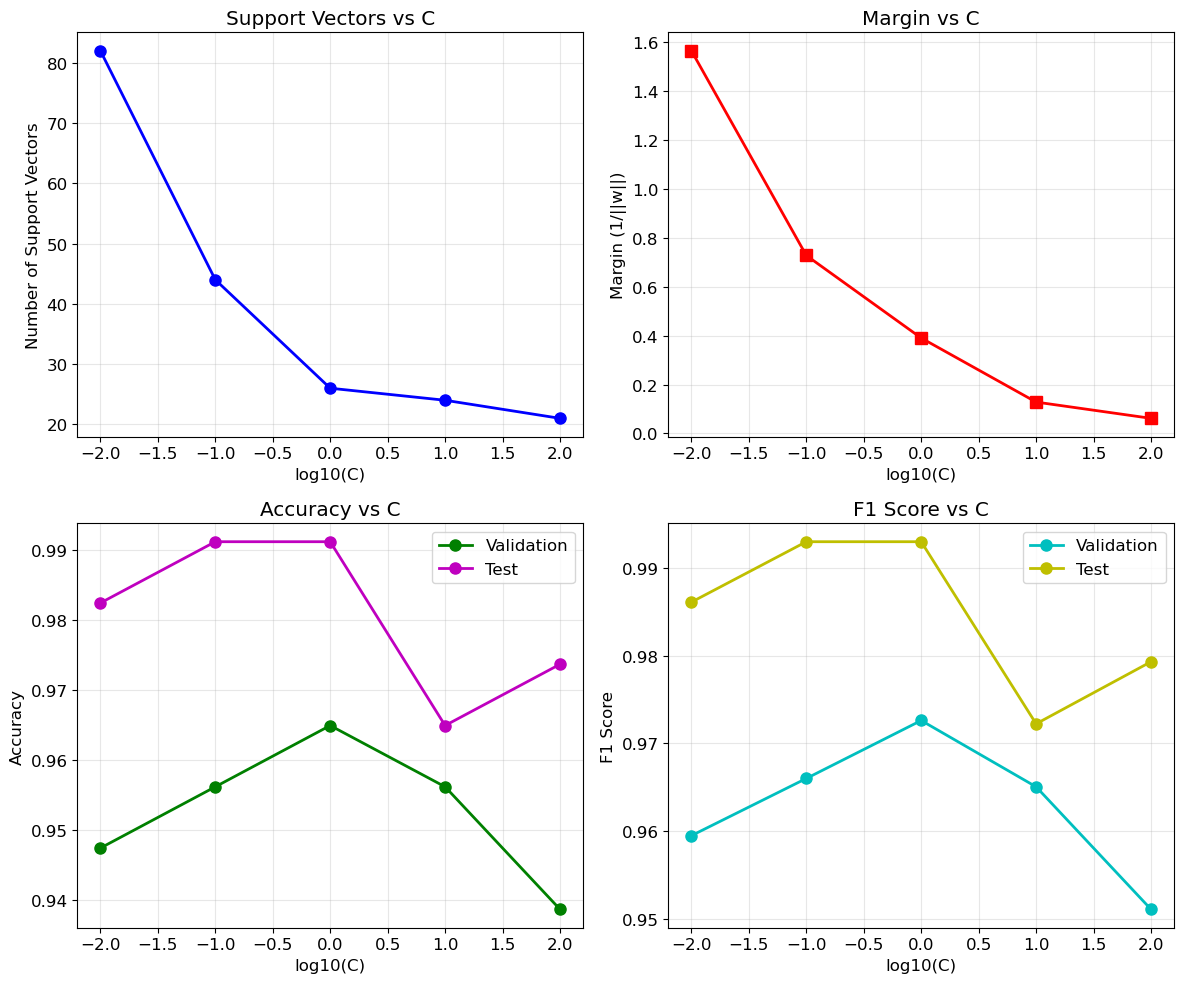

Plot saved: plots/Q7_C_analysis.png


In [213]:
# Plot C analysis
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

C_log = [np.log10(r['C']) for r in results_C]

axes[0, 0].plot(C_log, [r['n_sv'] for r in results_C], 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('log10(C)')
axes[0, 0].set_ylabel('Number of Support Vectors')
axes[0, 0].set_title('Support Vectors vs C')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(C_log, [r['margin'] for r in results_C], 'rs-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('log10(C)')
axes[0, 1].set_ylabel('Margin (1/||w||)')
axes[0, 1].set_title('Margin vs C')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(C_log, [r['val_acc'] for r in results_C], 'go-', linewidth=2, markersize=8, label='Validation')
axes[1, 0].plot(C_log, [r['test_acc'] for r in results_C], 'mo-', linewidth=2, markersize=8, label='Test')
axes[1, 0].set_xlabel('log10(C)')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('Accuracy vs C')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(C_log, [r['val_f1'] for r in results_C], 'co-', linewidth=2, markersize=8, label='Validation')
axes[1, 1].plot(C_log, [r['test_f1'] for r in results_C], 'yo-', linewidth=2, markersize=8, label='Test')
axes[1, 1].set_xlabel('log10(C)')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].set_title('F1 Score vs C')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/Q7_C_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: plots/Q7_C_analysis.png")


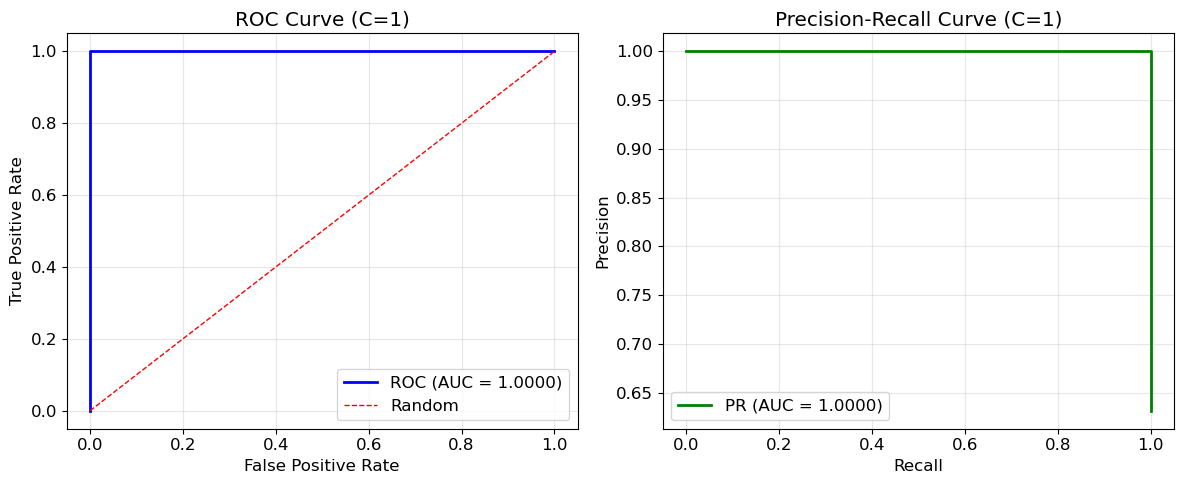

Plot saved: plots/Q7_roc_pr_curves.png

Best Model (C=1) Test Metrics:
  Accuracy: 0.9912
  Precision: 1.0000
  Recall: 0.9861
  F1: 0.9930
  ROC-AUC: 1.0000
  PR-AUC: 1.0000


In [214]:
# ROC and Precision-Recall Curves for best model
best_svm = SVC(kernel='linear', C=best_C)
best_svm.fit(X_train_scaled, y_train_svm)

y_test_scores = best_svm.decision_function(X_test_scaled)
fpr, tpr, _ = roc_curve(y_test_svm, y_test_scores)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_test_svm, y_test_scores)
pr_auc = auc(recall, precision)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title(f'ROC Curve (C={best_C})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(recall, precision, 'g-', linewidth=2, label=f'PR (AUC = {pr_auc:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'Precision-Recall Curve (C={best_C})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/Q7_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: plots/Q7_roc_pr_curves.png")

final_metrics = evaluate_svm(best_svm, X_val_scaled, y_val_svm, X_test_scaled, y_test_svm)
print(f"\nBest Model (C={best_C}) Test Metrics:")
print(f"  Accuracy: {final_metrics['test_acc']:.4f}")
print(f"  Precision: {final_metrics['test_prec']:.4f}")
print(f"  Recall: {final_metrics['test_rec']:.4f}")
print(f"  F1: {final_metrics['test_f1']:.4f}")
print(f"  ROC-AUC: {final_metrics['test_auc']:.4f}")
print(f"  PR-AUC: {pr_auc:.4f}")
